# Pre-Processing

In [ ]:
!pip install emoji --quiet

import pandas as pd
import re
import emoji
import time
from IPython.display import display

print(f"emoji version : {emoji.__version__}")
print("✓ Semua library berhasil diimport")

emoji version : 2.15.0
✓ Semua library berhasil diimport


## Load Dataset

In [ ]:
df = pd.read_csv('dataset_fix - scraped_tweets_5.csv')

print(f"Shape           : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Kolom           : {df.columns.tolist()}")
print(f"Missing values  : {df.isnull().sum().to_dict()}")
print(f"Duplikat (exact): {df['full_text'].duplicated().sum()} baris")
print()
display(df.head())

Shape           : 1669 baris x 2 kolom
Kolom           : ['full_text', 'Label']
Missing values  : {'full_text': 0, 'Label': 0}
Duplikat (exact): 2 baris



,full_text,Label
0,emang enak main sama tante bohay jangan lupa b...,1
1,sebelum berangkat memeknya harus dipenuhin pej...,1
2,Libur tapi sange #cs,0
3,@tanyarlfes ngatur bgt cowo lu kontol,0
4,@vioyinss Pernah. Malahan dulu waktu sd pernah...,0


## Konfigurasi Negation Whitelist & Stopword

In [ ]:
# Kata negasi yang WAJIB dipertahankan
# "tidak mau" ≠ "mau" — menghapus negasi adalah kesalahan fatal
NEGATION_WHITELIST = {
    'tidak', 'bukan', 'jangan', 'gak', 'ga', 'nggak',
    'ndak',  'tak',   'belum',  'tanpa', 'tiada'
}

# Stopword: hanya partikel, konjungsi, dan kata ganti
# tanpa muatan semantik — MINUS negation whitelist
STOPWORDS = {
    'yang', 'dan',     'di',       'ke',      'dari',   'ini',   'itu',
    'dengan','untuk',  'pada',     'adalah',  'dalam',  'akan',  'juga',
    'saya',  'aku',    'kamu',     'dia',     'mereka', 'kita',  'kami',
    'lah',   'pun',    'kan',      'deh',     'sih',    'nih',   'tuh',
    'aja',   'kok',    'yuk',      'ya',      'yah',    'wah',   'oh',
    'eh',    'atau',   'tapi',     'namun',   'tetapi', 'karena','oleh',
    'bagi',  'tentang','seperti',  'ketika',  'saat',   'bila',  'kalau',
    'jika',  'maka',   'agar',     'supaya',  'sudah',  'telah', 'pernah',
    'sangat','sekali', 'lebih',    'paling',  'hanya',  'cuma',  'saja',
    'lagi',  'lalu',   'kemudian', 'setelah', 'sebelum','nya',   'ku',
    'mu',    'si',     'sang',     'para',    'tersebut','bisa',  'biar',
    'dong',
} - NEGATION_WHITELIST

# Validasi: tidak ada irisan antara stopword dan negasi
irisan = STOPWORDS & NEGATION_WHITELIST
assert len(irisan) == 0, f"KONFLIK — kata ini ada di keduanya: {irisan}"

print(f"Jumlah stopword aktif : {len(STOPWORDS)}")
print(f"Jumlah kata negasi    : {len(NEGATION_WHITELIST)}")
print(f"Irisan (harus 0)      : {len(irisan)}")
print("✓ Konfigurasi valid")

Jumlah stopword aktif : 78
Jumlah kata negasi    : 11
Irisan (harus 0)      : 0
✓ Konfigurasi valid


## Fungsi Preprocessing

In [ ]:
def normalize_elongation(text: str) -> str:
    """
    Normalisasi elongasi huruf berulang lebih dari 2 kali.

    Contoh:
        'sangeeeee' → 'sangee'
        'cantiiiiik' → 'cantiik'
        'yaaaaa' → 'yaa'

    Mempertahankan 2 karakter karena elongasi 2 karakter
    masih membedakan dari kata aslinya dan menjaga nuansa
    emosi dalam teks informal.
    """
    return re.sub(r'(.)\1{2,}', r'\1\1', text)


def preprocess(text: str) -> str:
    """
    Preprocessing v2 — Semantic Preservation Strategy.

    Tahapan (urutan kritis, jangan diubah):

    1. Lowercase
    2. Hapus URL (https://, http://, www.)
    3. Anonimisasi @mention → token 'user' (lowercase)
    4. Demojize emoji → token teks
       🍆 → ':eggplant:' → 'emojieggplant'
    5. Normalisasi elongasi huruf
    6. Hapus karakter non-alfanumerik
    7. Hapus angka standalone
    8. Tokenisasi + stopword removal
       Kata negasi TIDAK dihapus (NEGATION_WHITELIST).
    9. Normalisasi spasi
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''

    # 1. Lowercase — dilakukan pertama agar semua step berikutnya
    #    bekerja pada teks yang seragam
    text = text.lower()

    # 2. Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Anonimisasi mention → 'user' (lowercase, aman dari regex step 6)
    text = re.sub(r'@\w+', 'user', text)

    # 4. Demojize emoji → prefix 'emoji' tanpa underscore
    #    Lowercase dulu baru demojize karena emoji.demojize butuh karakter asli
    #    Setelah demojize: 🍆 → ':eggplant:' → 'emojieggplant'
    #    Tidak pakai underscore agar aman dari regex step 6
    text = emoji.demojize(text, language='alias')
    text = re.sub(r':([a-z_]+):', lambda m: ' emoji' + m.group(1).replace('_', '') + ' ', text)

    # 5. Normalisasi elongasi
    text = normalize_elongation(text)

    # 6. Hapus karakter non-alfanumerik — sekarang aman karena
    #    'user' dan 'emojieggplant' hanya mengandung a-z
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 7. Hapus angka standalone
    text = re.sub(r'\b\d+\b', '', text)

    # 8. Tokenisasi + stopword removal
    tokens = [
        t for t in text.split()
        if t not in STOPWORDS or t in NEGATION_WHITELIST
    ]

    # 9. Normalisasi spasi
    return re.sub(r'\s+', ' ', ' '.join(tokens)).strip()


print("✓ Fungsi preprocess() dan normalize_elongation() siap")

✓ Fungsi preprocess() dan normalize_elongation() siap


## Tes pada Unit

In [ ]:
print("=" * 55)
print("UNIT TEST KOMPONEN PREPROCESSING")
print("=" * 55)

tests = [
    ("URL dihapus",
     preprocess("cek ini https://t.co/abc123 dulu"),
     lambda t: 'http' not in t and 't.co' not in t),

    ("Mention → user",
     preprocess("@budi maksa @ani pergi"),
     lambda t: 'user' in t and '@' not in t),

    ("Negasi dipertahankan",
     preprocess("gak mau tidak bisa dipaksa"),
     lambda t: 'gak' in t and 'tidak' in t),

    ("Stopword dihapus",
     preprocess("ini adalah kalimat yang sangat panjang"),
     lambda t: 'adalah' not in t and 'sangat' not in t),

    ("Elongasi dinormalisasi",
     preprocess("sangeeeee cantiiiiik"),
     lambda t: 'sangee' in t and 'cantiik' in t),

    ("Emoji → token emoji...",
     preprocess("mau 🍆 sama kamu"),
     lambda t: 'emojieggplant' in t),

    ("Input kosong tidak error",
     preprocess(""),
     lambda t: t == ''),

    ("Input None tidak error",
     preprocess(None),
     lambda t: t == ''),
]

semua_lulus = True
for nama, hasil, kondisi in tests:
    status = "✓" if kondisi(hasil) else "✗ GAGAL"
    print(f"  {status}  {nama}")
    print(f"         → '{hasil}'")
    if not kondisi(hasil):
        semua_lulus = False

print()
print("Semua test lulus ✓" if semua_lulus else "⚠️  Ada test yang gagal — cek konfigurasi")

UNIT TEST KOMPONEN PREPROCESSING
  ✓  URL dihapus
         → 'cek dulu'
  ✓  Mention → user
         → 'user maksa user pergi'
  ✓  Negasi dipertahankan
         → 'gak mau tidak dipaksa'
  ✓  Stopword dihapus
         → 'kalimat panjang'
  ✓  Elongasi dinormalisasi
         → 'sangee cantiik'
  ✓  Emoji → token emoji...
         → 'mau emojieggplant sama'
  ✓  Input kosong tidak error
         → ''
  ✓  Input None tidak error
         → ''

Semua test lulus ✓


## Preprocessing

In [ ]:
print("Memproses dataset...")
t0 = time.time()

df['full_text_clean'] = df['full_text'].apply(preprocess)

elapsed = time.time() - t0
print(f"✓ Selesai dalam {elapsed:.2f} detik untuk {len(df)} baris")

Memproses dataset...
✓ Selesai dalam 0.13 detik untuk 1669 baris


## Hapus Duplikat dan Missing Values

In [ ]:
# Drop baris yang hasilnya kosong setelah preprocessing
n_before_empty = len(df)
df = df[df['full_text_clean'].str.strip() != ''].reset_index(drop=True)
n_dropped_empty = n_before_empty - len(df)

# Drop duplikat SETELAH preprocessing
# Lebih akurat karena dua tweet berbeda bisa identik setelah dibersihkan
n_before_dup = len(df)
df = df.drop_duplicates(subset='full_text_clean').reset_index(drop=True)
n_dropped_dup = n_before_dup - len(df)

print(f"Baris kosong dihapus : {n_dropped_empty}")
print(f"Duplikat dihapus     : {n_dropped_dup}")
print(f"Dataset final        : {len(df)} baris")

Baris kosong dihapus : 0
Duplikat dihapus     : 50
Dataset final        : 1619 baris


## Validasi Hasil

In [ ]:
# Distribusi kelas
dist  = df['Label'].value_counts().sort_index()
ratio = df['Label'].value_counts(normalize=True).sort_index()

print("=" * 55)
print("DISTRIBUSI KELAS SETELAH PREPROCESSING")
print("=" * 55)
print(f"Label 0 — Non-KS : {dist[0]:>5} sampel ({ratio[0]*100:.1f}%)")
print(f"Label 1 — KS     : {dist[1]:>5} sampel ({ratio[1]*100:.1f}%)")
print(f"Imbalance Ratio  : {dist[0]/dist[1]:.2f}:1")
print()

# Validasi negasi dipertahankan
neg_pattern = r'\b(' + '|'.join(NEGATION_WHITELIST) + r')\b'
n_neg = df['full_text_clean'].str.contains(neg_pattern, regex=True).sum()
print(f"Tweet mengandung kata negasi : {n_neg} ({n_neg/len(df)*100:.1f}%)")
print()

# Validasi emoji token
n_emoji = df['full_text_clean'].str.contains('EMOJI_', na=False).sum()
print(f"Tweet dengan token EMOJI_    : {n_emoji}")
print("(0 = konsisten, dataset hampir tidak mengandung emoji)")
print()

# Sample perbandingan
print("=" * 55)
print("SAMPLE RAW vs CLEAN (5 baris acak)")
print("=" * 55)
for _, row in df.sample(5, random_state=42).iterrows():
    print(f"\n[Label {row['Label']}]")
    print(f"  RAW  : {str(row['full_text'])[:110]}")
    print(f"  CLEAN: {str(row['full_text_clean'])[:110]}")

DISTRIBUSI KELAS SETELAH PREPROCESSING
Label 0 — Non-KS :  1232 sampel (76.1%)
Label 1 — KS     :   387 sampel (23.9%)
Imbalance Ratio  : 3.18:1

Tweet mengandung kata negasi : 319 (19.7%)

Tweet dengan token EMOJI_    : 0
(0 = konsisten, dataset hampir tidak mengandung emoji)

SAMPLE RAW vs CLEAN (5 baris acak)

[Label 0]
  RAW  : gua sampe ada di tahap gak berharap ngeliat dia dihukum di dunia cukup liat aja entar di akhirat. gua tuntut s
  CLEAN: gua sampe ada tahap gak berharap ngeliat dihukum dunia cukup liat entar akhirat gua tuntut sampe tetek bengekn

[Label 1]
  RAW  : Kalau ini lewat DM aku ya mau aku kasih bacol
  CLEAN: lewat dm mau kasih bacol

[Label 0]
  RAW  : @fluxiedust Mulus banget percintaan orang yak LENAMIU AT CHANEL CRUISE #LenaMiuxChanelCruise
  CLEAN: user mulus banget percintaan orang yak lenamiu at chanel cruise lenamiuxchanelcruise

[Label 1]
  RAW  : pengen ngewe
  CLEAN: pengen ngewe

[Label 0]
  RAW  : @dailychaoss Marketing level dewa ini! Lemnya kuat ba

/tmp/ipykernel_2151/1477290690.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n_neg = df['full_text_clean'].str.contains(neg_pattern, regex=True).sum()


## Simpan Hasil

In [ ]:
output_path = 'dataset_preprocessed.csv'
df[['full_text_clean', 'Label']].to_csv(output_path, index=False)

# Verifikasi
df_check = pd.read_csv(output_path)
assert df_check.shape == df[['full_text_clean', 'Label']].shape

print(f"✓ File disimpan  : {output_path}")
print(f"  Shape          : {df_check.shape}")
print()
print("=" * 55)
print("BLOCK 2 SELESAI")
print(f"Input  : 1669 baris")
print(f"Output : {len(df_check)} baris")
print("Next   : Block 3 — EDA Komprehensif")
print("=" * 55)

✓ File disimpan  : dataset_preprocessed.csv
  Shape          : (1619, 2)

BLOCK 2 SELESAI
Input  : 1669 baris
Output : 1619 baris
Next   : Block 3 — EDA Komprehensif


# EDA

In [ ]:
!pip install matplotlib seaborn wordcloud --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from scipy import stats
from scipy.stats import chi2_contingency

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print("✓ Semua library siap")

✓ Semua library siap


## Load Data

In [ ]:
df = pd.read_csv('dataset_preprocessed.csv')

print(f"Shape  : {df.shape}")
print(f"Kolom  : {df.columns.tolist()}")
print(f"Missing: {df.isnull().sum().to_dict()}")
print()
df.head()

Shape  : (1619, 2)
Kolom  : ['full_text_clean', 'Label']
Missing: {'full_text_clean': 0, 'Label': 0}



,full_text_clean,Label
0,emang enak main sama tante bohay jangan lupa b...,1
1,berangkat memeknya harus dipenuhin peju papa d...,1
2,libur sange cs,0
3,user ngatur bgt cowo lu kontol,0
4,user malahan dulu waktu sd sama sepupu gak mas...,0


## Distribusi Kelas

In [ ]:
dist  = df['Label'].value_counts().sort_index()
ratio = df['Label'].value_counts(normalize=True).sort_index()

print("=" * 55)
print("DISTRIBUSI KELAS")
print("=" * 55)
print(f"Label 0 — Non-KS : {dist[0]:>5} sampel ({ratio[0]*100:.1f}%)")
print(f"Label 1 — KS     : {dist[1]:>5} sampel ({ratio[1]*100:.1f}%)")
print(f"Imbalance Ratio  : {dist[0]/dist[1]:.2f}:1")
print()
print("→ Imbalance dikonfirmasi. SMOTE diperlukan di Block 6.")

DISTRIBUSI KELAS
Label 0 — Non-KS :  1232 sampel (76.1%)
Label 1 — KS     :   387 sampel (23.9%)
Imbalance Ratio  : 3.18:1

→ Imbalance dikonfirmasi. SMOTE diperlukan di Block 6.


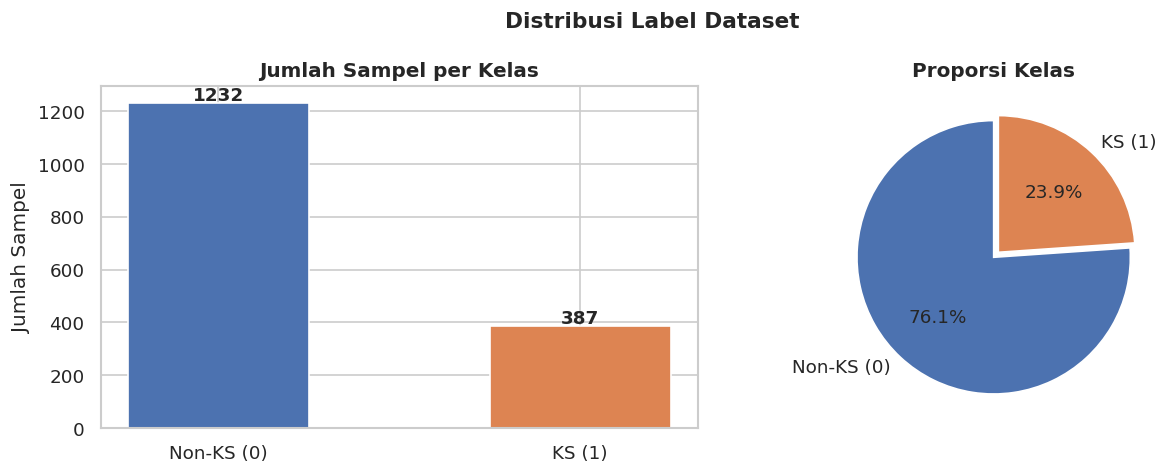

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#4C72B0', '#DD8452']

# Bar chart
axes[0].bar(['Non-KS (0)', 'KS (1)'], [dist[0], dist[1]],
            color=colors, width=0.5)
axes[0].set_title('Jumlah Sampel per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate([dist[0], dist[1]]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    [dist[0], dist[1]],
    labels=['Non-KS (0)', 'KS (1)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Proporsi Kelas', fontweight='bold')

plt.suptitle('Distribusi Label Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight')
plt.show()

## Statistik Panjang Teks

In [ ]:
df['char_len']   = df['full_text_clean'].str.len()
df['word_count'] = df['full_text_clean'].str.split().str.len()

print("=" * 55)
print("STATISTIK PANJANG TEKS PER KELAS")
print("=" * 55)
for label, nama in [(0, 'Non-KS'), (1, 'KS')]:
    sub = df[df['Label'] == label]
    print(f"Label {label} ({nama}) — n={len(sub)}:")
    print(f"  Karakter : mean={sub.char_len.mean():.0f}, "
          f"median={sub.char_len.median():.0f}, "
          f"max={sub.char_len.max()}")
    print(f"  Kata     : mean={sub.word_count.mean():.1f}, "
          f"median={sub.word_count.median():.0f}, "
          f"max={sub.word_count.max()}")
    print()

STATISTIK PANJANG TEKS PER KELAS
Label 0 (Non-KS) — n=1232:
  Karakter : mean=78, median=52, max=468
  Kata     : mean=12.7, median=9, max=83

Label 1 (KS) — n=387:
  Karakter : mean=62, median=43, max=259
  Kata     : mean=10.7, median=8, max=61



/tmp/ipykernel_2151/24020523.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[row_idx][0].boxplot(
/tmp/ipykernel_2151/24020523.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[row_idx][0].boxplot(


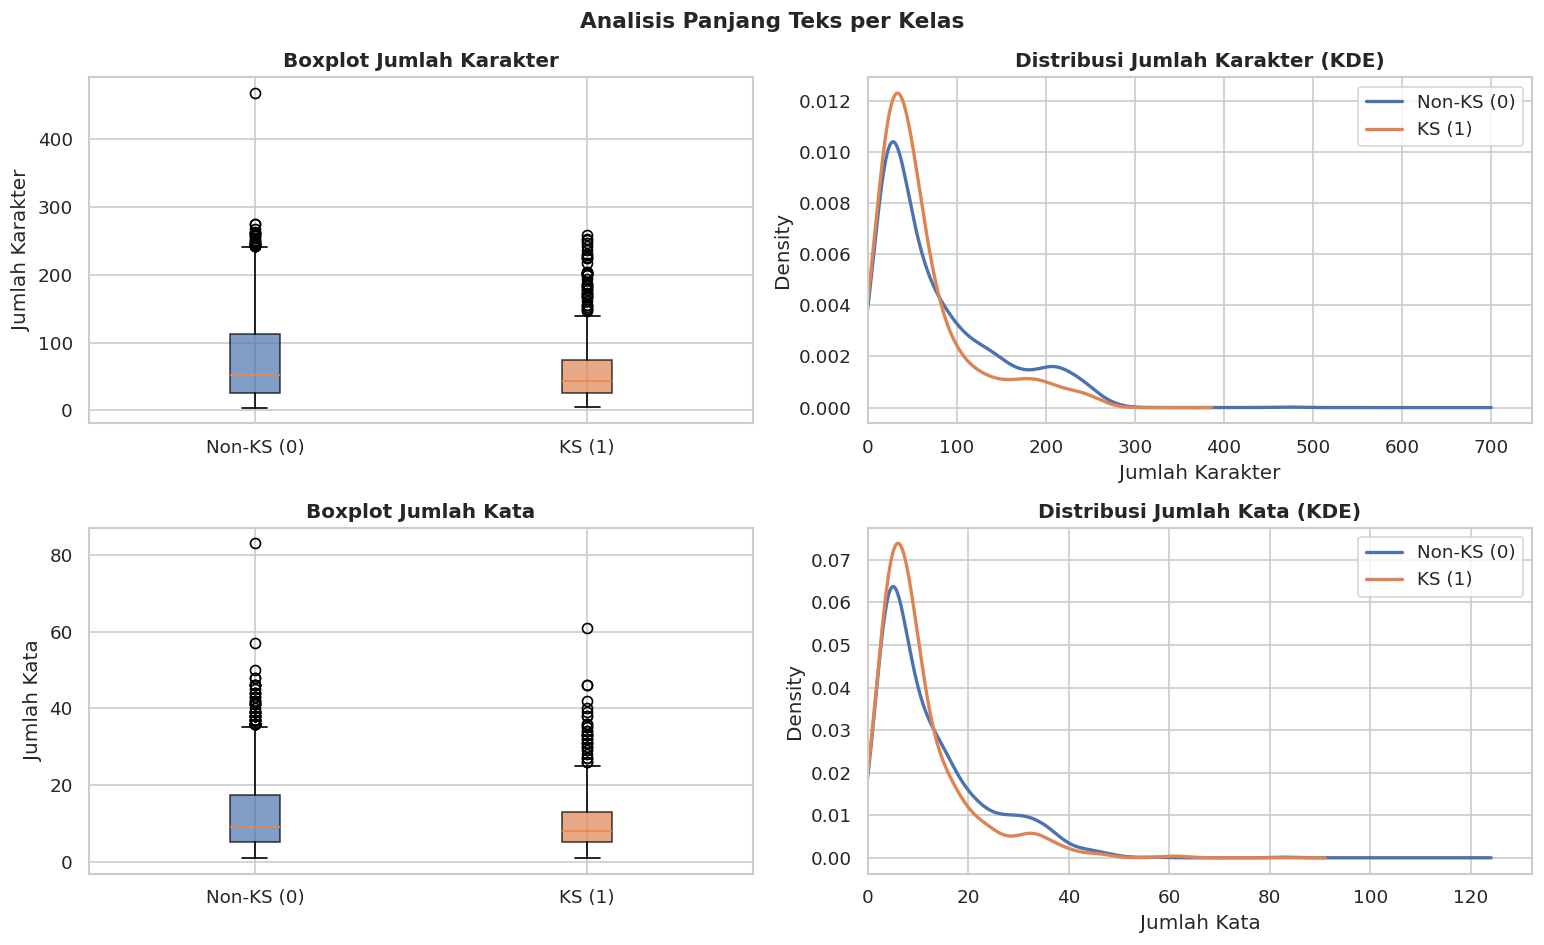

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = {0: '#4C72B0', 1: '#DD8452'}

for row_idx, (col, label_text) in enumerate([
    ('char_len',   'Jumlah Karakter'),
    ('word_count', 'Jumlah Kata')
]):
    # Boxplot
    data = [df[df['Label'] == l][col].values for l in [0, 1]]
    bp = axes[row_idx][0].boxplot(
        data, labels=['Non-KS (0)', 'KS (1)'],
        patch_artist=True, notch=False
    )
    for patch, c in zip(bp['boxes'], [colors[0], colors[1]]):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    axes[row_idx][0].set_title(f'Boxplot {label_text}', fontweight='bold')
    axes[row_idx][0].set_ylabel(label_text)

    # KDE
    for l in [0, 1]:
        df[df['Label'] == l][col].plot.kde(
            ax=axes[row_idx][1],
            label=f'{"Non-KS" if l==0 else "KS"} ({l})',
            color=colors[l], linewidth=2
        )
    axes[row_idx][1].set_title(f'Distribusi {label_text} (KDE)',
                                fontweight='bold')
    axes[row_idx][1].set_xlabel(label_text)
    axes[row_idx][1].legend()
    axes[row_idx][1].set_xlim(left=0)

plt.suptitle('Analisis Panjang Teks per Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_text_length.png', bbox_inches='tight')
plt.show()

## Konfigurasi dengan Keyword Scraping

In [ ]:
# Keyword dari dua sesi scraping
# Digunakan untuk analisis lexical bias

KEYWORDS_SCRAPE1 = {
    'cantik','cewek','gede','besar','ketat','cowok','nafsu','genit','goda',
    'sentuh','becek','kedut','tegak','birahi','mulus','susu','seksi','montok',
    'bening','body','lekuk','menggoda','pegang','raba','remas','peluk','cium',
    'dekati','ganggu','sange','napsu','pengen','modus','gatel','nakal','liar',
    'menggairahkan'
}

KEYWORDS_SCRAPE2 = {
    'seksi','bohay','sange','kontol','memek','ewek','ngewe','ngentod',
    'bacol','coli','jilmek','sepong','sangean','crot','birahi','nafsu',
    'grepe','toket','tetek','bugil','perkosa'
}

ALL_KEYWORDS = KEYWORDS_SCRAPE1 | KEYWORDS_SCRAPE2

print(f"Keyword scraping 1   : {len(KEYWORDS_SCRAPE1)}")
print(f"Keyword scraping 2   : {len(KEYWORDS_SCRAPE2)}")
print(f"Overlap keduanya     : {len(KEYWORDS_SCRAPE1 & KEYWORDS_SCRAPE2)}")
print(f"Total keyword unik   : {len(ALL_KEYWORDS)}")

Keyword scraping 1   : 37
Keyword scraping 2   : 21
Overlap keduanya     : 4
Total keyword unik   : 54


## Profanity Density + Mann-Whitney U Test

In [ ]:
def count_keyword_hits(text, keywords):
    tokens = set(str(text).split())
    return len(tokens & keywords)

df['kw_hits'] = df['full_text_clean'].apply(
    lambda x: count_keyword_hits(x, ALL_KEYWORDS)
)
df['profanity_density'] = df['kw_hits'] / df['word_count'].replace(0, 1)

# Mann-Whitney U Test (non-parametric)
ks_density  = df[df['Label'] == 1]['profanity_density']
non_density = df[df['Label'] == 0]['profanity_density']
u_stat, p_val = stats.mannwhitneyu(ks_density, non_density, alternative='greater')

print("=" * 55)
print("PROFANITY DENSITY PER KELAS")
print("=" * 55)
print(df.groupby('Label')['profanity_density'].describe().round(3).to_string())
print()
print("Mann-Whitney U Test (KS > Non-KS):")
print(f"  U statistic : {u_stat:.0f}")
print(f"  p-value     : {p_val:.4e}")
print(f"  Signifikan  : {'YA (p < 0.05)' if p_val < 0.05 else 'TIDAK'}")

PROFANITY DENSITY PER KELAS
        count   mean    std  min    25%    50%   75%  max
Label                                                    
0      1232.0  0.155  0.129  0.0  0.059  0.111  0.20  1.0
1       387.0  0.188  0.145  0.0  0.098  0.143  0.25  1.0

Mann-Whitney U Test (KS > Non-KS):
  U statistic : 283132
  p-value     : 1.1620e-08
  Signifikan  : YA (p < 0.05)


/tmp/ipykernel_2151/1670776674.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


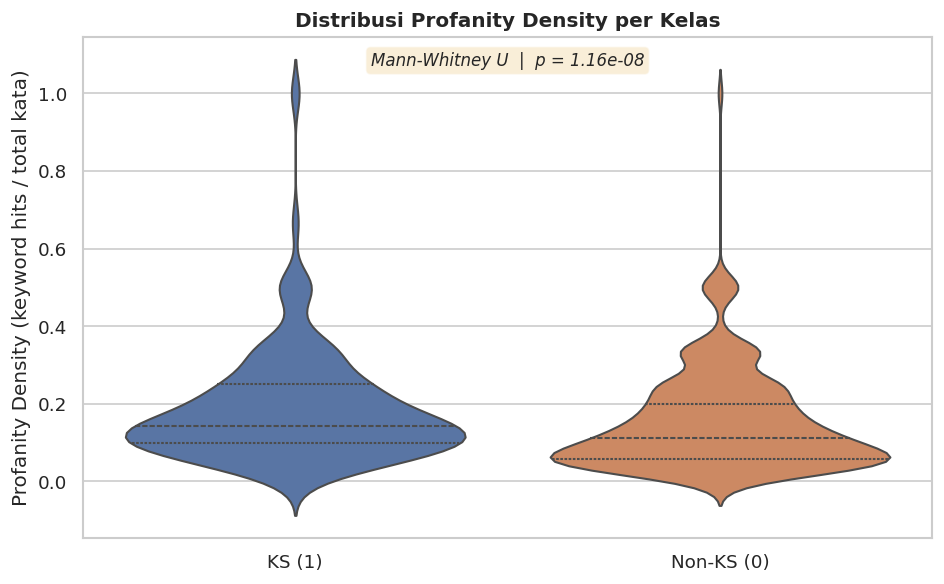

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = pd.DataFrame({
    'Kelas'            : df['Label'].map({0: 'Non-KS (0)', 1: 'KS (1)'}),
    'Profanity Density': df['profanity_density']
})

sns.violinplot(
    data=plot_data, x='Kelas', y='Profanity Density',
    palette=['#4C72B0', '#DD8452'],
    inner='quartile', ax=ax
)
ax.set_title('Distribusi Profanity Density per Kelas', fontweight='bold')
ax.set_ylabel('Profanity Density (keyword hits / total kata)')
ax.set_xlabel('')
ax.text(0.5, 0.97,
        f'Mann-Whitney U  |  p = {p_val:.2e}',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('plot_03_profanity_density.png', bbox_inches='tight')
plt.show()

## Lexical Overlap (IoU) per Keyword

In [ ]:
iou_results = []
for kw in ALL_KEYWORDS:
    pattern  = r'\b' + kw + r'\b'
    in_ks    = df[df['Label'] == 1]['full_text_clean'].str.contains(pattern, regex=True).sum()
    in_non   = df[df['Label'] == 0]['full_text_clean'].str.contains(pattern, regex=True).sum()
    total    = in_ks + in_non
    if total == 0:
        continue
    iou = round(min(in_ks, in_non) / max(in_ks, in_non), 3)
    iou_results.append({
        'Keyword'     : kw,
        'Dalam KS'    : in_ks,
        'Dalam Non-KS': in_non,
        'Total'       : total,
        'IoU'         : iou,
        'Sumber'      : 'S1+S2' if kw in KEYWORDS_SCRAPE1 and kw in KEYWORDS_SCRAPE2
                        else ('S1' if kw in KEYWORDS_SCRAPE1 else 'S2')
    })

iou_df = pd.DataFrame(iou_results).sort_values('Total', ascending=False).reset_index(drop=True)

print("Top 15 keyword berdasarkan frekuensi:")
print(iou_df.head(15).to_string(index=False))
print()
biased = iou_df[iou_df['IoU'] > 0.5]
print(f"Keyword dengan IoU > 0.5 (high lexical bias): {len(biased)}")

Top 15 keyword berdasarkan frekuensi:
Keyword  Dalam KS  Dalam Non-KS  Total   IoU Sumber
 pengen        23           216    239 0.106     S1
 kontol        59           164    223 0.360     S2
 cantik        10           165    175 0.061     S1
  sange        84            87    171 0.966  S1+S2
  besar         4           121    125 0.033     S1
   gede        16            92    108 0.174     S1
  ngewe        40            42     82 0.952     S2
   coli        28            32     60 0.875     S2
  memek        34            25     59 0.735     S2
  nafsu        10            48     58 0.208  S1+S2
   crot        31            17     48 0.548     S2
  cewek         5            38     43 0.132     S1
  cowok         6            35     41 0.171     S1
  seksi        24            14     38 0.583  S1+S2
 pegang         4            26     30 0.154     S1

Keyword dengan IoU > 0.5 (high lexical bias): 12


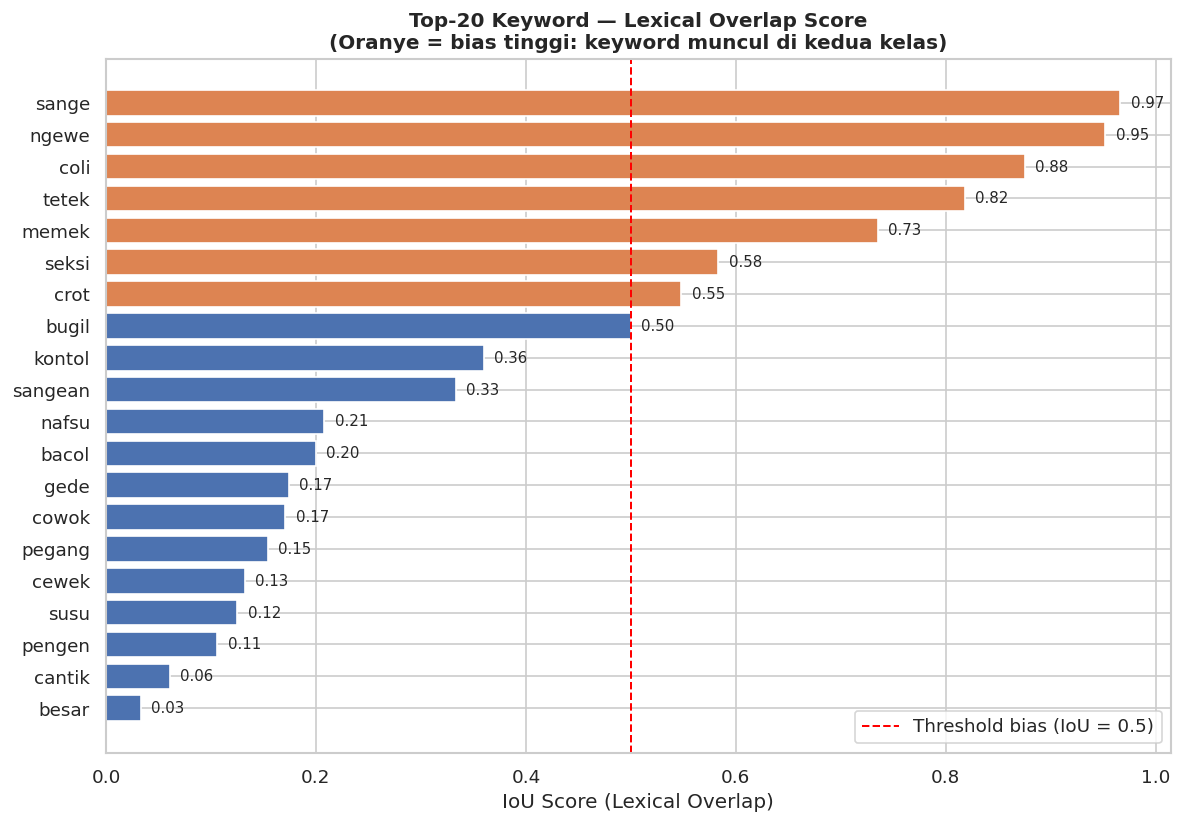

In [ ]:
top20 = iou_df.head(20).sort_values('IoU', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#DD8452' if v > 0.5 else '#4C72B0' for v in top20['IoU']]
bars = ax.barh(top20['Keyword'], top20['IoU'], color=bar_colors)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.2,
           label='Threshold bias (IoU = 0.5)')
ax.set_xlabel('IoU Score (Lexical Overlap)')
ax.set_title('Top-20 Keyword — Lexical Overlap Score\n'
             '(Oranye = bias tinggi: keyword muncul di kedua kelas)',
             fontweight='bold')
ax.legend()
for bar, val in zip(bars, top20['IoU']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_04_lexical_bias_iou.png', bbox_inches='tight')
plt.show()

## Log Odds per Kelas

In [ ]:
def get_word_counts(texts):
    counter = Counter()
    for t in texts:
        counter.update(str(t).split())
    return counter

cnt0 = get_word_counts(df[df['Label'] == 0]['full_text_clean'])
cnt1 = get_word_counts(df[df['Label'] == 1]['full_text_clean'])
vocab = set(cnt0.keys()) | set(cnt1.keys())
n0, n1 = sum(cnt0.values()), sum(cnt1.values())

log_odds_list = []
for w in vocab:
    if len(w) < 3:
        continue
    p0 = (cnt0[w] + 1) / (n0 + len(vocab))
    p1 = (cnt1[w] + 1) / (n1 + len(vocab))
    freq_total = cnt0[w] + cnt1[w]
    if freq_total < 3:
        continue
    log_odds_list.append({
        'word'      : w,
        'log_odds'  : np.log(p1 / p0),
        'freq_total': freq_total
    })

lo_df = pd.DataFrame(log_odds_list).sort_values('log_odds', ascending=False)

print("Top 15 kata diskriminatif — KS:")
print(lo_df.head(15)[['word', 'log_odds', 'freq_total']].to_string(index=False))
print()
print("Top 15 kata diskriminatif — Non-KS:")
print(lo_df.tail(15)[['word', 'log_odds', 'freq_total']].to_string(index=False))

Top 15 kata diskriminatif — KS:
             word  log_odds  freq_total
emojiarrowforward  3.145720          10
            binor  3.050410           9
            tante  3.050410           9
         brondong  2.945050           8
              ara  2.827267           7
          dientot  2.693735           6
         kontolin  2.539585           5
           gabisa  2.539585           5
             peju  2.539585           5
         suaminya  2.539585           5
          pejuhin  2.357263           4
             papa  2.357263          10
             imut  2.357263           4
            doggy  2.251903           9
            doyan  2.251903           9

Top 15 kata diskriminatif — Non-KS:
     word  log_odds  freq_total
     masa -1.960225          14
   negeri -2.024764          15
      tni -2.024764          15
   bangsa -2.085388          16
     lucu -2.085388          16
   negara -2.142547          17
   semoga -2.196614          18
  seorang -2.196614          18
   

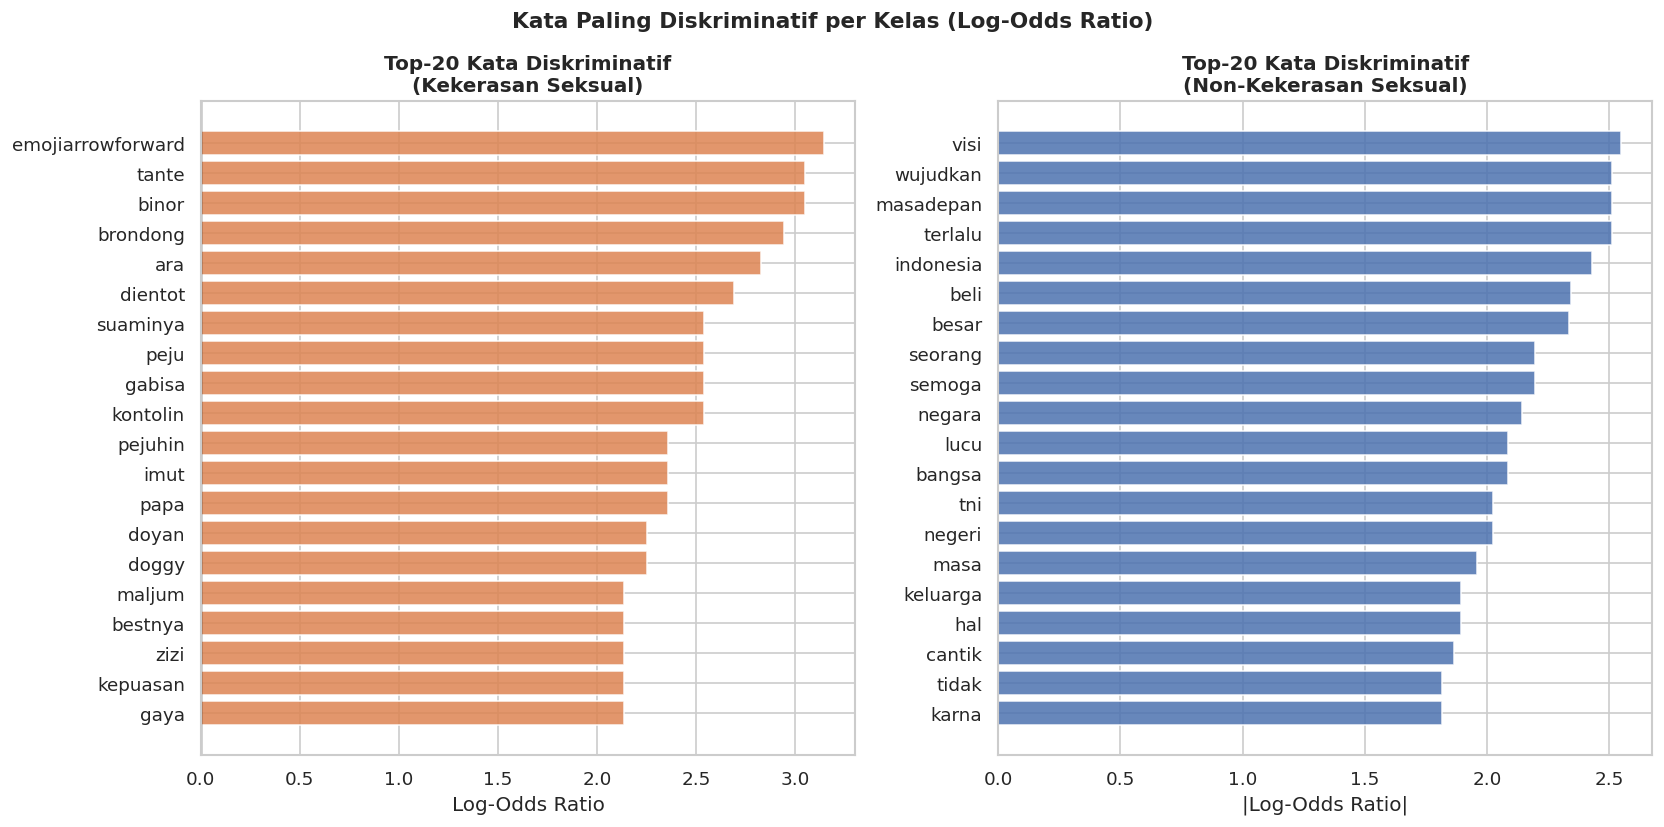

In [ ]:
top_ks     = lo_df.head(20).sort_values('log_odds')
top_non_ks = lo_df.tail(20).sort_values('log_odds', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top_ks['word'], top_ks['log_odds'],
             color='#DD8452', alpha=0.85)
axes[0].set_title('Top-20 Kata Diskriminatif\n(Kekerasan Seksual)',
                  fontweight='bold')
axes[0].set_xlabel('Log-Odds Ratio')
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].barh(top_non_ks['word'], top_non_ks['log_odds'].abs(),
             color='#4C72B0', alpha=0.85)
axes[1].set_title('Top-20 Kata Diskriminatif\n(Non-Kekerasan Seksual)',
                  fontweight='bold')
axes[1].set_xlabel('|Log-Odds Ratio|')

plt.suptitle('Kata Paling Diskriminatif per Kelas (Log-Odds Ratio)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_log_odds.png', bbox_inches='tight')
plt.show()

## Word Cloud per Kelas

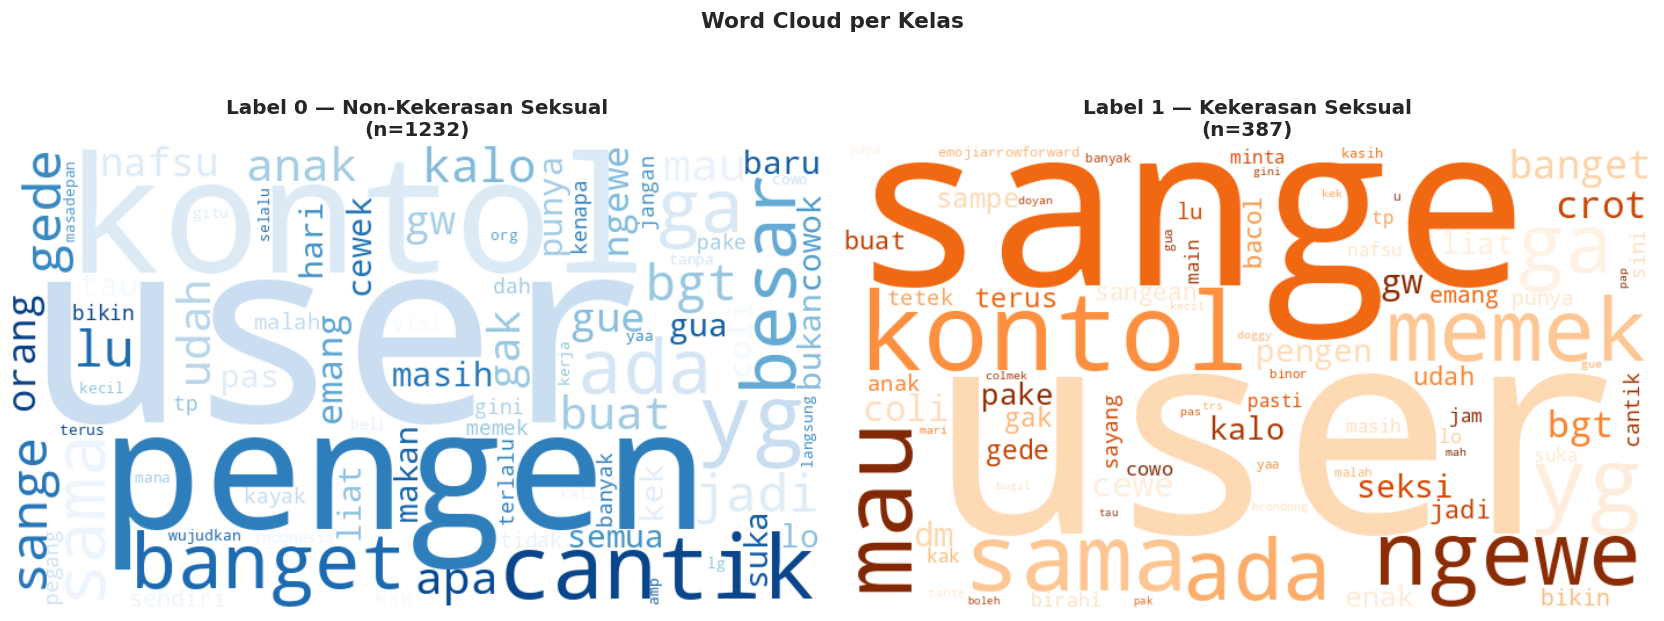

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label, nama, cmap in [(0, 'Non-Kekerasan Seksual', 'Blues'),
                           (1, 'Kekerasan Seksual',     'Oranges')]:
    teks = ' '.join(df[df['Label'] == label]['full_text_clean'].astype(str))
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=cmap,
        max_words=80,
        min_font_size=8,
        collocations=False
    ).generate(teks)
    axes[label].imshow(wc, interpolation='bilinear')
    axes[label].axis('off')
    axes[label].set_title(f'Label {label} — {nama}\n(n={dist[label]})',
                           fontweight='bold', fontsize=12)

plt.suptitle('Word Cloud per Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_wordcloud.png', bbox_inches='tight')
plt.show()

## Validasi has_negation (Chi-Square)

In [ ]:
NEGATION_WHITELIST = {
    'tidak', 'bukan', 'jangan', 'gak', 'ga', 'nggak',
    'ndak',  'tak',   'belum',  'tanpa', 'tiada'
}
neg_pattern = r'\b(' + '|'.join(NEGATION_WHITELIST) + r')\b'
df['has_negation'] = df['full_text_clean'].str.contains(
    neg_pattern, regex=True).astype(int)

ct = pd.crosstab(df['has_negation'], df['Label'])
chi2, p, dof, _ = chi2_contingency(ct)

print("=" * 55)
print("CHI-SQUARE TEST — has_negation vs Label")
print("=" * 55)
print(f"Chi2 statistic : {chi2:.4f}")
print(f"p-value        : {p:.4e}")
print(f"Derajat bebas  : {dof}")
print(f"Signifikan     : {'YA (p < 0.05)' if p < 0.05 else 'TIDAK'}")
print()
print("Contingency Table:")
print(ct.to_string())

CHI-SQUARE TEST — has_negation vs Label
Chi2 statistic : 2.4815
p-value        : 1.1519e-01
Derajat bebas  : 1
Signifikan     : TIDAK

Contingency Table:
Label           0    1
has_negation          
0             978  322
1             254   65


/tmp/ipykernel_2151/1052924359.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_negation'] = df['full_text_clean'].str.contains(


## Ringkasan Temuan EDA

In [ ]:
print("=" * 60)
print("RINGKASAN TEMUAN EDA")
print("=" * 60)
print()
print("1. CLASS IMBALANCE")
print(f"   Rasio {dist[0]/dist[1]:.2f}:1 (Non-KS:KS)")
print(f"   → SMOTE diperlukan di Block 6")
print()
print("2. PANJANG TEKS")
print(f"   KS  : mean {df[df['Label']==1]['word_count'].mean():.1f} kata")
print(f"   Non-KS: mean {df[df['Label']==0]['word_count'].mean():.1f} kata")
print(f"   → Tweet KS cenderung lebih pendek dan langsung")
print()
print("3. PROFANITY DENSITY")
print(f"   KS    : mean={df[df['Label']==1]['profanity_density'].mean():.3f}")
print(f"   Non-KS: mean={df[df['Label']==0]['profanity_density'].mean():.3f}")
print(f"   Mann-Whitney p={p_val:.2e} → signifikan")
print()
print("4. LEXICAL BIAS")
biased = iou_df[iou_df['IoU'] > 0.5]
print(f"   {len(biased)} dari {len(iou_df)} keyword IoU > 0.5")
print(f"   → Mitigasi: feature selection (Block 4) + IndoBERT (Block 7)")
print()
print("5. HAS_NEGATION")
print(f"   Chi-Square p={p:.2e} → {'signifikan' if p < 0.05 else 'tidak signifikan'}")
print()
print("=" * 60)

RINGKASAN TEMUAN EDA

1. CLASS IMBALANCE
   Rasio 3.18:1 (Non-KS:KS)
   → SMOTE diperlukan di Block 6

2. PANJANG TEKS
   KS  : mean 10.7 kata
   Non-KS: mean 12.7 kata
   → Tweet KS cenderung lebih pendek dan langsung

3. PROFANITY DENSITY
   KS    : mean=0.188
   Non-KS: mean=0.155
   Mann-Whitney p=1.16e-08 → signifikan

4. LEXICAL BIAS
   12 dari 51 keyword IoU > 0.5
   → Mitigasi: feature selection (Block 4) + IndoBERT (Block 7)

5. HAS_NEGATION
   Chi-Square p=1.15e-01 → tidak signifikan



# Feature Engineering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2, SelectKBest, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("✓ Library siap")

✓ Library siap


##  Feature Engineering

In [ ]:
# ── Definisi keyword ─────────────────────────────────────────
KEYWORDS_SCRAPE1 = {
    'cantik','cewek','gede','besar','ketat','cowok','nafsu','genit','goda',
    'sentuh','becek','kedut','tegak','birahi','mulus','susu','seksi','montok',
    'bening','body','lekuk','menggoda','pegang','raba','remas','peluk','cium',
    'dekati','ganggu','sange','napsu','pengen','modus','gatel','nakal','liar',
    'menggairahkan'
}
KEYWORDS_SCRAPE2 = {
    'seksi','bohay','sange','kontol','memek','ewek','ngewe','ngentod',
    'bacol','coli','jilmek','sepong','sangean','crot','birahi','nafsu',
    'grepe','toket','tetek','bugil','perkosa'
}
ALL_KEYWORDS = KEYWORDS_SCRAPE1 | KEYWORDS_SCRAPE2

NEGATION_WHITELIST = {
    'tidak','bukan','jangan','gak','ga','nggak',
    'ndak','tak','belum','tanpa','tiada'
}

# ── Fitur 1: profanity_density ────────────────────────────────
# Rasio kata vulgar terhadap total kata per tweet
def count_keyword_hits(text, keywords):
    tokens = set(str(text).split())
    return len(tokens & keywords)

df['word_count']        = df['full_text_clean'].str.split().str.len()
df['kw_hits']           = df['full_text_clean'].apply(
                              lambda x: count_keyword_hits(x, ALL_KEYWORDS))
df['profanity_density'] = df['kw_hits'] / df['word_count'].replace(0, 1)

# ── Fitur 2: has_negation ─────────────────────────────────────
# Keberadaan kata negasi (biner)
neg_pattern = r'\b(' + '|'.join(NEGATION_WHITELIST) + r')\b'
df['has_negation'] = df['full_text_clean'].str.contains(
                         neg_pattern, regex=True).astype(int)

# ── Fitur 3: emoji_count ──────────────────────────────────────
# Jumlah token emoji dalam tweet
df['emoji_count'] = df['full_text_clean'].str.count(r'emoji\w+')

print("Fitur engineered berhasil dibuat:")
print(df[['profanity_density','has_negation','emoji_count']].describe().round(3).to_string())

Fitur engineered berhasil dibuat:
       profanity_density  has_negation  emoji_count
count           1619.000      1619.000     1619.000
mean               0.163         0.197        0.012
std                0.133         0.398        0.166
min                0.000         0.000        0.000
25%                0.067         0.000        0.000
50%                0.125         0.000        0.000
75%                0.222         0.000        0.000
max                1.000         1.000        4.000


/tmp/ipykernel_2151/585886991.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_negation'] = df['full_text_clean'].str.contains(


## TF-IDF + Gabungkan Fitur

In [ ]:
# ── TF-IDF Vectorization ─────────────────────────────────────
# unigram + bigram, max 5000 fitur
# Ini representasi numerik utama untuk teks

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,           # Abaikan term yang muncul < 2 dokumen
    sublinear_tf=True   # Log normalization untuk mengurangi dominasi frekuensi tinggi
)

X_tfidf = tfidf.fit_transform(df['full_text_clean'].astype(str))

print(f"Shape TF-IDF matrix : {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]} dokumen x {X_tfidf.shape[1]} fitur")

# ── Gabungkan TF-IDF + fitur engineered ──────────────────────
# Fitur engineered di-stack ke kanan matrix TF-IDF
engineered = df[['profanity_density','has_negation','emoji_count']].values
X_engineered_sparse = sp.csr_matrix(engineered)
X_full = sp.hstack([X_tfidf, X_engineered_sparse])

y = df['Label'].values

print(f"\nShape X_full (TF-IDF + engineered) : {X_full.shape}")
print(f"  → {X_full.shape[1]} fitur total")

Shape TF-IDF matrix : (1619, 3027)
  → 1619 dokumen x 3027 fitur

Shape X_full (TF-IDF + engineered) : (1619, 3030)
  → 3030 fitur total


## Train/Test Split

In [ ]:
# Stratified split: distribusi kelas dipertahankan di train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} sampel")
print(f"Test  : {X_test.shape[0]} sampel")
print(f"Train label dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  label dist: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Train : 1295 sampel
Test  : 324 sampel
Train label dist: {np.int64(0): np.int64(985), np.int64(1): np.int64(310)}
Test  label dist: {np.int64(0): np.int64(247), np.int64(1): np.int64(77)}


## Baseline (Tanpa Feature Engineering)

In [ ]:
from sklearn.metrics import f1_score, classification_report

# Baseline: semua 5003 fitur (5000 TF-IDF + 3 engineered)
lr_baseline = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

t0 = time.time()
lr_baseline.fit(X_train, y_train)
t_baseline = time.time() - t0

y_pred_baseline = lr_baseline.predict(X_test)
f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')

print("=" * 55)
print("BASELINE — Semua Fitur (tanpa feature selection)")
print("=" * 55)
print(f"Jumlah fitur   : {X_train.shape[1]}")
print(f"Waktu training : {t_baseline:.3f} detik")
print(f"F1-Macro       : {f1_baseline:.4f}")
print()
print(classification_report(y_test, y_pred_baseline,
      target_names=['Non-KS', 'KS']))

BASELINE — Semua Fitur (tanpa feature selection)
Jumlah fitur   : 3030
Waktu training : 0.161 detik
F1-Macro       : 0.7467

              precision    recall  f1-score   support

      Non-KS       0.88      0.87      0.88       247
          KS       0.61      0.62      0.62        77

    accuracy                           0.81       324
   macro avg       0.74      0.75      0.75       324
weighted avg       0.82      0.81      0.82       324



##  Feature Selection Metode 1: Chi-Square (Filter)

In [ ]:
# ── Chi-Square Filter Method ──────────────────────────────────
# Mengukur dependensi statistik antara setiap fitur dan label.
# Fitur dengan chi2 score tinggi = lebih diskriminatif.
# Tidak melibatkan model → sangat cepat.
# Referensi: Yang & Pedersen (1997)

K_CHI2 = 1000  # Ambil top-1000 fitur

selector_chi2 = SelectKBest(chi2, k=K_CHI2)

t0 = time.time()
X_train_chi2 = selector_chi2.fit_transform(X_train, y_train)
X_test_chi2  = selector_chi2.transform(X_test)
t_chi2_select = time.time() - t0

# Train model dengan fitur terpilih
t0 = time.time()
lr_chi2 = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_chi2.fit(X_train_chi2, y_train)
t_chi2_train = time.time() - t0

y_pred_chi2 = lr_chi2.predict(X_test_chi2)
f1_chi2 = f1_score(y_test, y_pred_chi2, average='macro')

print("=" * 55)
print("METODE 1 — Chi-Square (Filter Method)")
print("=" * 55)
print(f"Fitur sebelum seleksi : {X_train.shape[1]}")
print(f"Fitur setelah seleksi : {X_train_chi2.shape[1]}")
print(f"Reduksi fitur         : {(1 - K_CHI2/X_train.shape[1])*100:.1f}%")
print(f"Waktu seleksi         : {t_chi2_select:.3f} detik")
print(f"Waktu training        : {t_chi2_train:.3f} detik")
print(f"F1-Macro              : {f1_chi2:.4f}")
print()
print(classification_report(y_test, y_pred_chi2,
      target_names=['Non-KS', 'KS']))

METODE 1 — Chi-Square (Filter Method)
Fitur sebelum seleksi : 3030
Fitur setelah seleksi : 1000
Reduksi fitur         : 67.0%
Waktu seleksi         : 0.032 detik
Waktu training        : 0.111 detik
F1-Macro              : 0.7418

              precision    recall  f1-score   support

      Non-KS       0.89      0.85      0.87       247
          KS       0.58      0.65      0.61        77

    accuracy                           0.81       324
   macro avg       0.73      0.75      0.74       324
weighted avg       0.81      0.81      0.81       324



## Feature Selection Metode 2: RFE (Wrapper)

In [ ]:
# ── Recursive Feature Elimination (Wrapper Method) ───────────
# Melatih model secara iteratif, membuang fitur dengan bobot
# terkecil di setiap iterasi hingga tersisa K fitur.
# Lebih akurat dari Chi-Square tapi lebih mahal secara komputasi.
# Referensi: Guyon et al. (2002)

K_RFE = 1000  # Sama dengan Chi-Square untuk perbandingan adil

# Gunakan LR sebagai estimator dasar
lr_rfe_base = LogisticRegression(
    class_weight='balanced',
    max_iter=500,
    random_state=42,
    solver='saga'       # Solver yang efisien untuk sparse matrix besar
)

selector_rfe = RFE(
    estimator=lr_rfe_base,
    n_features_to_select=K_RFE,
    step=500,           # Buang 500 fitur per iterasi (lebih cepat)
    verbose=1
)

print("Menjalankan RFE (butuh beberapa menit)...")
t0 = time.time()
X_train_rfe = selector_rfe.fit_transform(X_train, y_train)
X_test_rfe  = selector_rfe.transform(X_test)
t_rfe_select = time.time() - t0

# Train model dengan fitur RFE
t0 = time.time()
lr_rfe = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_rfe.fit(X_train_rfe, y_train)
t_rfe_train = time.time() - t0

y_pred_rfe = lr_rfe.predict(X_test_rfe)
f1_rfe = f1_score(y_test, y_pred_rfe, average='macro')

print()
print("=" * 55)
print("METODE 2 — RFE (Wrapper Method)")
print("=" * 55)
print(f"Fitur sebelum seleksi : {X_train.shape[1]}")
print(f"Fitur setelah seleksi : {X_train_rfe.shape[1]}")
print(f"Reduksi fitur         : {(1 - K_RFE/X_train.shape[1])*100:.1f}%")
print(f"Waktu seleksi         : {t_rfe_select:.2f} detik")
print(f"Waktu training        : {t_rfe_train:.3f} detik")
print(f"F1-Macro              : {f1_rfe:.4f}")
print()
print(classification_report(y_test, y_pred_rfe,
      target_names=['Non-KS', 'KS']))

Menjalankan RFE (butuh beberapa menit)...
Fitting estimator with 3030 features.
Fitting estimator with 2530 features.
Fitting estimator with 2030 features.
Fitting estimator with 1530 features.
Fitting estimator with 1030 features.

METODE 2 — RFE (Wrapper Method)
Fitur sebelum seleksi : 3030
Fitur setelah seleksi : 1000
Reduksi fitur         : 67.0%
Waktu seleksi         : 3.17 detik
Waktu training        : 0.180 detik
F1-Macro              : 0.7397

              precision    recall  f1-score   support

      Non-KS       0.88      0.86      0.87       247
          KS       0.58      0.64      0.61        77

    accuracy                           0.81       324
   macro avg       0.73      0.75      0.74       324
weighted avg       0.81      0.81      0.81       324



## Perbandingan

In [ ]:
# Tabel ini menjawab Soal 1a secara langsung:
# "jelaskan perbedaannya terhadap jumlah fitur yang terpilih"

results = pd.DataFrame([
    {
        'Metode'              : 'Baseline (semua fitur)',
        'Tipe'                : '—',
        'Jumlah Fitur'        : X_train.shape[1],
        'Reduksi (%)'         : 0.0,
        'F1-Macro'            : round(f1_baseline, 4),
        'Waktu Training (s)'  : round(t_baseline, 3),
    },
    {
        'Metode'              : 'Chi-Square',
        'Tipe'                : 'Filter',
        'Jumlah Fitur'        : K_CHI2,
        'Reduksi (%)'         : round((1 - K_CHI2/X_train.shape[1])*100, 1),
        'F1-Macro'            : round(f1_chi2, 4),
        'Waktu Training (s)'  : round(t_chi2_train, 3),
    },
    {
        'Metode'              : 'RFE',
        'Tipe'                : 'Wrapper',
        'Jumlah Fitur'        : K_RFE,
        'Reduksi (%)'         : round((1 - K_RFE/X_train.shape[1])*100, 1),
        'F1-Macro'            : round(f1_rfe, 4),
        'Waktu Training (s)'  : round(t_rfe_train, 3),
    },
])

print("=" * 70)
print("PERBANDINGAN METODE FEATURE SELECTION")
print("=" * 70)
print(results.to_string(index=False))
print()

# Simpan untuk referensi Block berikutnya
best_method = results.loc[results['F1-Macro'].idxmax(), 'Metode']
best_f1     = results['F1-Macro'].max()
print(f"Metode terbaik : {best_method} (F1-Macro = {best_f1:.4f})")

PERBANDINGAN METODE FEATURE SELECTION
                Metode    Tipe  Jumlah Fitur  Reduksi (%)  F1-Macro  Waktu Training (s)
Baseline (semua fitur)       —          3030          0.0    0.7467               0.161
            Chi-Square  Filter          1000         67.0    0.7418               0.111
                   RFE Wrapper          1000         67.0    0.7397               0.180

Metode terbaik : Baseline (semua fitur) (F1-Macro = 0.7467)


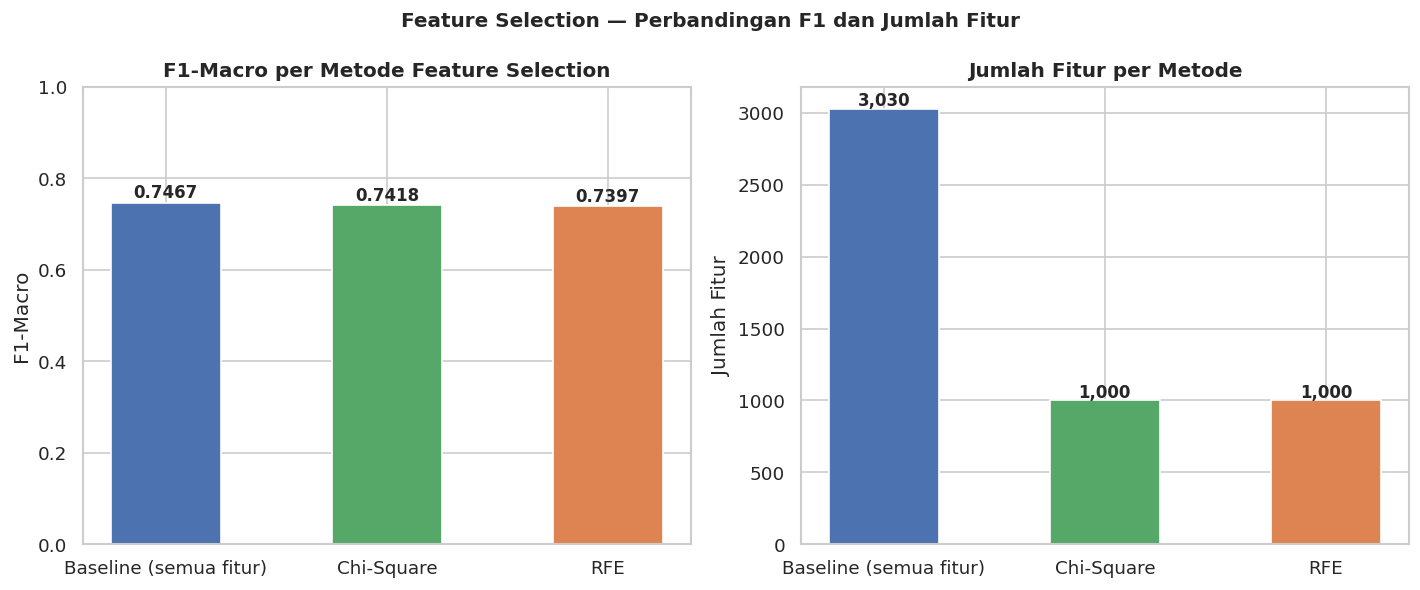

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#55A868', '#DD8452']
methods = results['Metode'].tolist()

# F1-Macro comparison
bars0 = axes[0].bar(methods, results['F1-Macro'], color=colors, width=0.5)
axes[0].set_title('F1-Macro per Metode Feature Selection', fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars0, results['F1-Macro']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# Jumlah fitur comparison
bars1 = axes[1].bar(methods, results['Jumlah Fitur'], color=colors, width=0.5)
axes[1].set_title('Jumlah Fitur per Metode', fontweight='bold')
axes[1].set_ylabel('Jumlah Fitur')
for bar, val in zip(bars1, results['Jumlah Fitur']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Feature Selection — Perbandingan F1 dan Jumlah Fitur',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_feature_selection.png', bbox_inches='tight')
plt.show()

In [ ]:
import joblib

# Simpan selector Chi-Square dan RFE untuk digunakan di block berikutnya
joblib.dump(selector_chi2, 'selector_chi2.pkl')
joblib.dump(selector_rfe,  'selector_rfe.pkl')
joblib.dump(tfidf,         'tfidf_vectorizer.pkl')

# Simpan juga info feature selection untuk referensi
results.to_csv('feature_selection_results.csv', index=False)

print("=" * 55)
print("✓ Tersimpan:")
print("  selector_chi2.pkl")
print("  selector_rfe.pkl")
print("  tfidf_vectorizer.pkl")
print("  feature_selection_results.csv")
print("=" * 55)

✓ Tersimpan:
  selector_chi2.pkl
  selector_rfe.pkl
  tfidf_vectorizer.pkl
  feature_selection_results.csv


# Dimensionality Reduction: PCA + t-SNE

In [ ]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import time

print("✓ Library siap")

✓ Library siap


##  PCA: Cari Jumlah Komponen Optimal

In [ ]:
# PCA tidak bisa langsung pada sparse matrix
# Gunakan TruncatedSVD — ekuivalen dengan PCA untuk data sparse
# Referensi: Halko et al. (2011) — randomized SVD untuk sparse matrix besar

# Step 1: Fit TruncatedSVD dengan n_components besar dulu
# untuk melihat berapa komponen yang menjelaskan 90% variance

svd_full = TruncatedSVD(n_components=200, random_state=42)
svd_full.fit(X_train)

# Cumulative explained variance
cumvar = np.cumsum(svd_full.explained_variance_ratio_)

# Cari n_components untuk threshold variance
thresholds = [0.70, 0.80, 0.90]
n_for_threshold = {}
for t in thresholds:
    n = np.argmax(cumvar >= t) + 1
    n_for_threshold[t] = n
    print(f"  {int(t*100)}% variance explained oleh {n} komponen")

print(f"\nTotal fitur asli : {X_train.shape[1]}")

  70% variance explained oleh 1 komponen
  80% variance explained oleh 1 komponen
  90% variance explained oleh 1 komponen

Total fitur asli : 3030


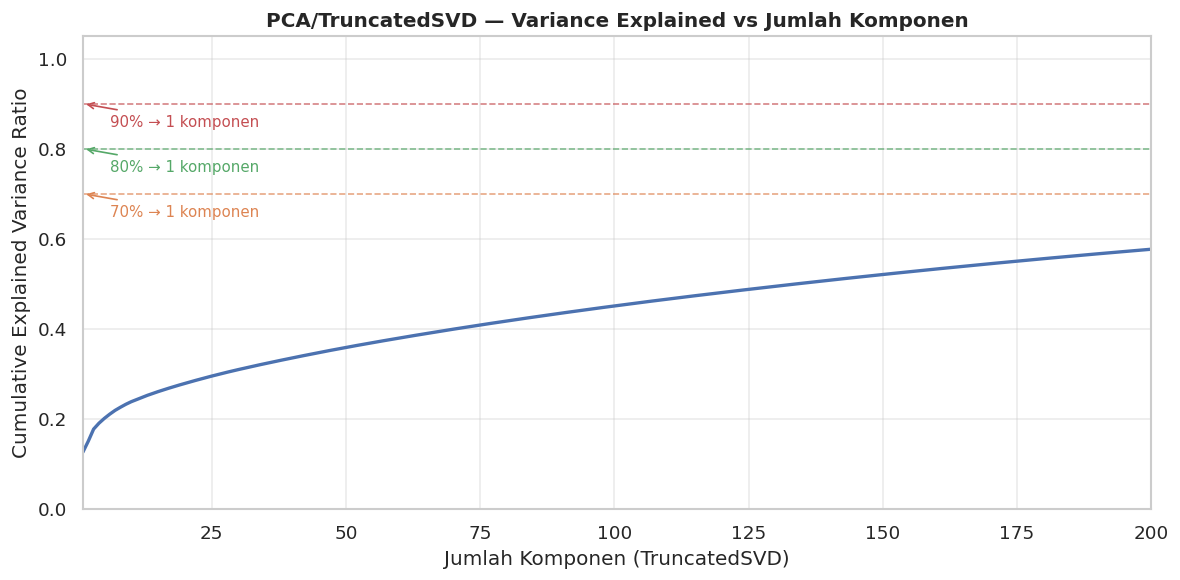

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(cumvar)+1), cumvar,
        color='#4C72B0', linewidth=2)

# Tandai threshold
colors_t = ['#DD8452', '#55A868', '#C44E52']
for (t, n), c in zip(n_for_threshold.items(), colors_t):
    ax.axhline(y=t, color=c, linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=n, color=c, linestyle='--', linewidth=1, alpha=0.7)
    ax.annotate(f'{int(t*100)}% → {n} komponen',
                xy=(n, t), xytext=(n+5, t-0.05),
                fontsize=9, color=c,
                arrowprops=dict(arrowstyle='->', color=c, lw=1))

ax.set_xlabel('Jumlah Komponen (TruncatedSVD)')
ax.set_ylabel('Cumulative Explained Variance Ratio')
ax.set_title('PCA/TruncatedSVD — Variance Explained vs Jumlah Komponen',
             fontweight='bold')
ax.set_xlim(1, 200)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('plot_08_pca_variance.png', bbox_inches='tight')
plt.show()

## PCA: Evaluasi F1 vs Jumlah Komponen

In [ ]:
# Uji beberapa konfigurasi n_components
# untuk melihat trade-off akurasi vs efisiensi

configs = [50, 100, n_for_threshold[0.80], n_for_threshold[0.90], 200]
configs = sorted(set(configs))  # Hilangkan duplikat

pca_results = []
for n in configs:
    # Fit SVD
    svd = TruncatedSVD(n_components=n, random_state=42)
    t0  = time.time()
    X_tr_pca = svd.fit_transform(X_train)
    X_te_pca = svd.transform(X_test)
    t_transform = time.time() - t0

    # Train LR
    t0  = time.time()
    lr  = LogisticRegression(class_weight='balanced',
                              max_iter=1000, random_state=42)
    lr.fit(X_tr_pca, y_train)
    t_train = time.time() - t0

    y_pred = lr.predict(X_te_pca)
    f1     = f1_score(y_test, y_pred, average='macro')
    cumv   = np.sum(svd.explained_variance_ratio_)

    pca_results.append({
        'n_components'       : n,
        'Variance Explained' : round(cumv, 3),
        'F1-Macro'           : round(f1, 4),
        'Waktu Transform (s)': round(t_transform, 3),
        'Waktu Training (s)' : round(t_train, 3),
        'Total Waktu (s)'    : round(t_transform + t_train, 3),
    })
    print(f"  n={n:>4} | var={cumv:.3f} | F1={f1:.4f} | "
          f"waktu={t_transform+t_train:.3f}s")

pca_df = pd.DataFrame(pca_results)
print()
print(pca_df.to_string(index=False))

  n=   1 | var=0.125 | F1=0.3331 | waktu=0.054s
  n=  50 | var=0.356 | F1=0.7279 | waktu=0.819s
  n= 100 | var=0.448 | F1=0.7366 | waktu=1.287s
  n= 200 | var=0.576 | F1=0.7358 | waktu=2.623s

 n_components  Variance Explained  F1-Macro  Waktu Transform (s)  Waktu Training (s)  Total Waktu (s)
            1               0.125    0.3331                0.043               0.010            0.054
           50               0.356    0.7279                0.681               0.138            0.819
          100               0.448    0.7366                1.171               0.117            1.287
          200               0.576    0.7358                2.513               0.110            2.623


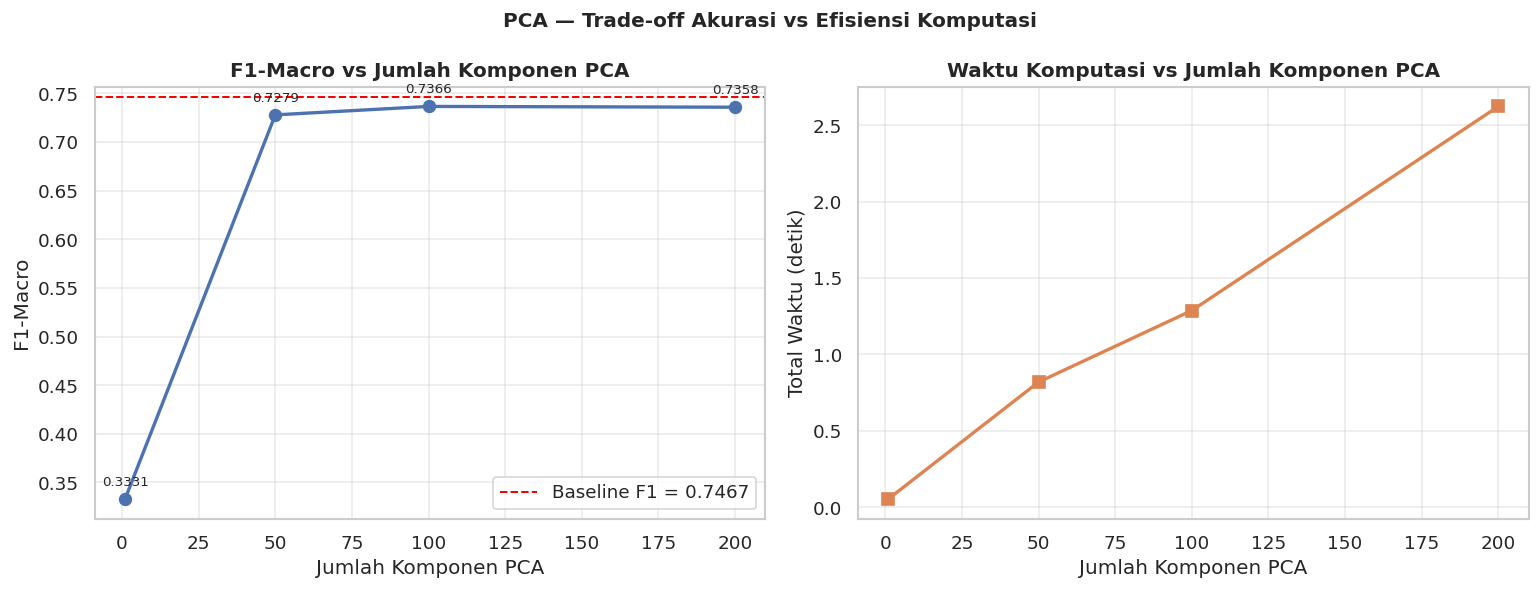

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F1 vs n_components
axes[0].plot(pca_df['n_components'], pca_df['F1-Macro'],
             marker='o', color='#4C72B0', linewidth=2, markersize=7)
axes[0].axhline(y=0.7467, color='red', linestyle='--',
                linewidth=1.2, label=f'Baseline F1 = 0.7467')
axes[0].set_xlabel('Jumlah Komponen PCA')
axes[0].set_ylabel('F1-Macro')
axes[0].set_title('F1-Macro vs Jumlah Komponen PCA', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
for _, row in pca_df.iterrows():
    axes[0].annotate(f"{row['F1-Macro']:.4f}",
                     (row['n_components'], row['F1-Macro']),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)

# Total waktu vs n_components
axes[1].plot(pca_df['n_components'], pca_df['Total Waktu (s)'],
             marker='s', color='#DD8452', linewidth=2, markersize=7)
axes[1].set_xlabel('Jumlah Komponen PCA')
axes[1].set_ylabel('Total Waktu (detik)')
axes[1].set_title('Waktu Komputasi vs Jumlah Komponen PCA', fontweight='bold')
axes[1].grid(True, alpha=0.4)

plt.suptitle('PCA — Trade-off Akurasi vs Efisiensi Komputasi',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_09_pca_tradeoff.png', bbox_inches='tight')
plt.show()

##  t-SNE Visualisasi

In [ ]:
# t-SNE untuk visualisasi separabilitas kelas dalam 2D
# Gunakan TruncatedSVD 50 komponen dulu sebelum t-SNE
# karena t-SNE sangat lambat pada dimensi tinggi
# Referensi: Van der Maaten & Hinton (2008)

print("Step 1: Reduksi ke 50 dimensi dengan TruncatedSVD dulu...")
svd_50 = TruncatedSVD(n_components=50, random_state=42)
X_svd50 = svd_50.fit_transform(X_full)
print(f"  Shape setelah SVD: {X_svd50.shape}")

print("Step 2: t-SNE ke 2D (butuh 1-3 menit)...")
t0 = time.time()
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    init='pca',
    random_state=42,
    n_iter=1000
)
X_tsne = tsne.fit_transform(X_svd50)
elapsed = time.time() - t0
print(f"  Selesai dalam {elapsed:.1f} detik")
print(f"  Shape t-SNE output: {X_tsne.shape}")

Step 1: Reduksi ke 50 dimensi dengan TruncatedSVD dulu...
  Shape setelah SVD: (1619, 50)
Step 2: t-SNE ke 2D (butuh 1-3 menit)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  Selesai dalam 106.9 detik
  Shape t-SNE output: (1619, 2)


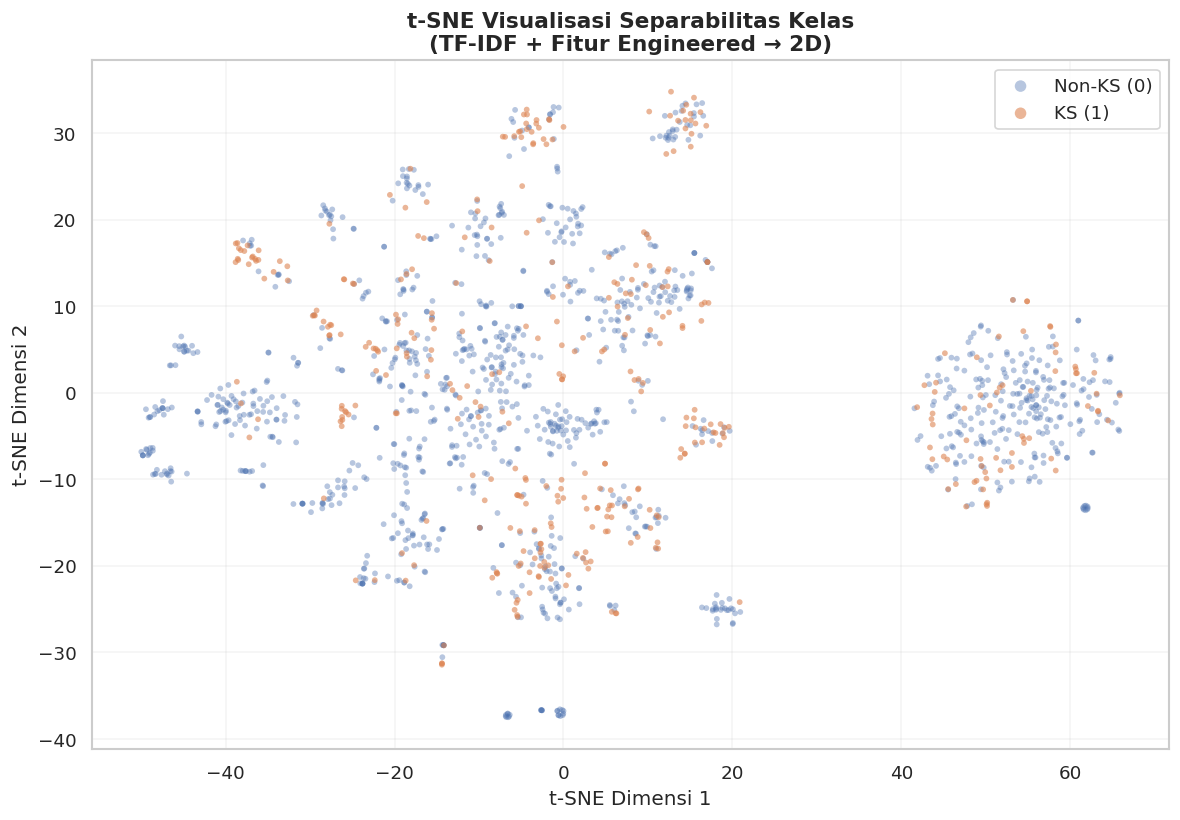


Interpretasi:
  Cluster terpisah  → fitur sudah cukup diskriminatif
  Overlap tinggi    → model butuh representasi lebih kaya (IndoBERT)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

colors  = {0: '#4C72B0', 1: '#DD8452'}
labels  = {0: 'Non-KS (0)', 1: 'KS (1)'}
alphas  = {0: 0.4, 1: 0.6}

for label in [0, 1]:
    mask = y == label
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=colors[label],
        label=labels[label],
        alpha=alphas[label],
        s=12,
        edgecolors='none'
    )

ax.set_title('t-SNE Visualisasi Separabilitas Kelas\n'
             '(TF-IDF + Fitur Engineered → 2D)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimensi 1')
ax.set_ylabel('t-SNE Dimensi 2')
ax.legend(markerscale=2, fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('plot_10_tsne.png', bbox_inches='tight', dpi=150)
plt.show()

print()
print("Interpretasi:")
print("  Cluster terpisah  → fitur sudah cukup diskriminatif")
print("  Overlap tinggi    → model butuh representasi lebih kaya (IndoBERT)")

In [ ]:
print("=" * 65)
print("RINGKASAN — DIMENSIONALITY REDUCTION")
print("=" * 65)
print()
print("PCA (TruncatedSVD) — Trade-off Akurasi vs Efisiensi:")
print(pca_df[['n_components','Variance Explained',
              'F1-Macro','Total Waktu (s)']].to_string(index=False))
print()

baseline_f1 = 0.7467
best_pca    = pca_df.loc[pca_df['F1-Macro'].idxmax()]
drop_min    = baseline_f1 - pca_df['F1-Macro'].max()

print(f"Baseline F1 (tanpa PCA)    : {baseline_f1:.4f}")
print(f"F1 terbaik dengan PCA      : {best_pca['F1-Macro']:.4f} "
      f"(n={int(best_pca['n_components'])})")
print(f"Penurunan F1 minimum       : {drop_min:.4f}")
print()

# Konfigurasi dengan penurunan F1 terkecil
print("Konfigurasi PCA terbaik yang tersedia:")
print(f"  n_components       : {int(best_pca['n_components'])}")
print(f"  Variance explained : {best_pca['Variance Explained']:.1%}")
print(f"  F1-Macro           : {best_pca['F1-Macro']:.4f}")
print(f"  Total waktu        : {best_pca['Total Waktu (s)']:.3f} detik")
print()

# Simpan untuk referensi paper
pca_df.to_csv('pca_results.csv', index=False)

print("Kesimpulan:")
if drop_min > 0.01:
    print(f"  Semua konfigurasi PCA menurunkan F1 > 0.01 dari baseline.")
    print(f"  PCA tidak menghasilkan efisiensi yang sebanding untuk dataset ini.")
    print(f"  Penyebab: TF-IDF sparse matrix sudah relatif efisien;")
    print(f"  reduksi dimensi menghilangkan fitur diskriminatif.")
    print(f"  → t-SNE tetap berguna untuk visualisasi (bukan untuk modeling).")
else:
    print(f"  PCA dengan n={int(best_pca['n_components'])} komponen")
    print(f"  mempertahankan F1 dalam toleransi 0.01 dari baseline.")

print()
print("=" * 65)

RINGKASAN — DIMENSIONALITY REDUCTION

PCA (TruncatedSVD) — Trade-off Akurasi vs Efisiensi:
 n_components  Variance Explained  F1-Macro  Total Waktu (s)
            1               0.125    0.3331            0.054
           50               0.356    0.7279            0.819
          100               0.448    0.7366            1.287
          200               0.576    0.7358            2.623

Baseline F1 (tanpa PCA)    : 0.7467
F1 terbaik dengan PCA      : 0.7366 (n=100)
Penurunan F1 minimum       : 0.0101

Konfigurasi PCA terbaik yang tersedia:
  n_components       : 100
  Variance explained : 44.8%
  F1-Macro           : 0.7366
  Total waktu        : 1.287 detik

Kesimpulan:
  Semua konfigurasi PCA menurunkan F1 > 0.01 dari baseline.
  PCA tidak menghasilkan efisiensi yang sebanding untuk dataset ini.
  Penyebab: TF-IDF sparse matrix sudah relatif efisien;
  reduksi dimensi menghilangkan fitur diskriminatif.
  → t-SNE tetap berguna untuk visualisasi (bukan untuk modeling).



# Imbalanced Data Handling

In [ ]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, classification_report,
                              roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.sparse as sp
import joblib
import time

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("✓ Library siap")

✓ Library siap


## Baseline: Evaluasi Sebelum SMOTE

In [ ]:
# Evaluasi model dengan data asli (imbalanced)
# Ini adalah titik pembanding untuk mengukur dampak SMOTE

lr_before = LogisticRegression(
    class_weight='balanced',   # LR sudah punya mekanisme class weighting
    max_iter=1000,
    random_state=42
)

t0 = time.time()
lr_before.fit(X_train, y_train)
t_before = time.time() - t0

y_pred_before = lr_before.predict(X_test)
y_prob_before = lr_before.predict_proba(X_test)[:, 1]

f1_before  = f1_score(y_test, y_pred_before, average='macro')
auc_before = roc_auc_score(y_test, y_prob_before)

print("=" * 55)
print("SEBELUM SMOTE (imbalanced training data)")
print("=" * 55)
print(f"Train dist : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"F1-Macro   : {f1_before:.4f}")
print(f"ROC-AUC    : {auc_before:.4f}")
print(f"Waktu fit  : {t_before:.3f} detik")
print()
print(classification_report(y_test, y_pred_before,
      target_names=['Non-KS', 'KS']))

SEBELUM SMOTE (imbalanced training data)
Train dist : {np.int64(0): np.int64(985), np.int64(1): np.int64(310)}
F1-Macro   : 0.7467
ROC-AUC    : 0.8475
Waktu fit  : 0.231 detik

              precision    recall  f1-score   support

      Non-KS       0.88      0.87      0.88       247
          KS       0.61      0.62      0.62        77

    accuracy                           0.81       324
   macro avg       0.74      0.75      0.75       324
weighted avg       0.82      0.81      0.82       324



## Terapkan SMOTE

In [ ]:
# SMOTE hanya pada training set — TIDAK pernah pada test set
# Menerapkan SMOTE pada test set adalah data leakage

# SMOTE: buat sampel sintetis untuk kelas minoritas
# dengan interpolasi antara sampel yang ada dan tetangganya (k-NN)
# Referensi: Chawla et al. (2002)

smote = SMOTE(
    sampling_strategy='minority',  # Oversample kelas minoritas (KS)
    k_neighbors=5,                 # Default k-NN
    random_state=42
)

print("Menjalankan SMOTE pada training set...")
t0 = time.time()
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
t_smote = time.time() - t0

dist_after = dict(zip(*np.unique(y_train_smote, return_counts=True)))

print(f"Selesai dalam {t_smote:.2f} detik")
print()
print(f"Distribusi train SEBELUM SMOTE : "
      f"{dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Distribusi train SETELAH SMOTE : {dist_after}")
print(f"Total sampel train sebelum     : {X_train.shape[0]}")
print(f"Total sampel train setelah     : {X_train_smote.shape[0]}")
print(f"Sampel sintetis ditambahkan    : "
      f"{X_train_smote.shape[0] - X_train.shape[0]}")

Menjalankan SMOTE pada training set...
Selesai dalam 0.06 detik

Distribusi train SEBELUM SMOTE : {np.int64(0): np.int64(985), np.int64(1): np.int64(310)}
Distribusi train SETELAH SMOTE : {np.int64(0): np.int64(985), np.int64(1): np.int64(985)}
Total sampel train sebelum     : 1295
Total sampel train setelah     : 1970
Sampel sintetis ditambahkan    : 675


## Evaluasi Setelah SMOTE

In [ ]:
lr_after = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

t0 = time.time()
lr_after.fit(X_train_smote, y_train_smote)
t_after = time.time() - t0

y_pred_after = lr_after.predict(X_test)
y_prob_after = lr_after.predict_proba(X_test)[:, 1]

f1_after  = f1_score(y_test, y_pred_after, average='macro')
auc_after = roc_auc_score(y_test, y_prob_after)

print("=" * 55)
print("SETELAH SMOTE (balanced training data)")
print("=" * 55)
print(f"Train dist : {dist_after}")
print(f"F1-Macro   : {f1_after:.4f}")
print(f"ROC-AUC    : {auc_after:.4f}")
print(f"Waktu fit  : {t_after:.3f} detik")
print()
print(classification_report(y_test, y_pred_after,
      target_names=['Non-KS', 'KS']))

SETELAH SMOTE (balanced training data)
Train dist : {np.int64(0): np.int64(985), np.int64(1): np.int64(985)}
F1-Macro   : 0.7539
ROC-AUC    : 0.8525
Waktu fit  : 0.375 detik

              precision    recall  f1-score   support

      Non-KS       0.88      0.89      0.89       247
          KS       0.64      0.61      0.62        77

    accuracy                           0.82       324
   macro avg       0.76      0.75      0.75       324
weighted avg       0.82      0.82      0.82       324



## Tabel Perbandingan Before vs After

In [ ]:
comparison = pd.DataFrame([
    {
        'Kondisi'           : 'Sebelum SMOTE',
        'Train Samples'     : X_train.shape[0],
        'KS di Train'       : dict(zip(*np.unique(y_train, return_counts=True)))[1],
        'F1-Macro'          : round(f1_before, 4),
        'ROC-AUC'           : round(auc_before, 4),
        'Waktu Fit (s)'     : round(t_before, 3),
    },
    {
        'Kondisi'           : 'Setelah SMOTE',
        'Train Samples'     : X_train_smote.shape[0],
        'KS di Train'       : dist_after[1],
        'F1-Macro'          : round(f1_after, 4),
        'ROC-AUC'           : round(auc_after, 4),
        'Waktu Fit (s)'     : round(t_after, 3),
    },
])

print("=" * 70)
print("PERBANDINGAN BEFORE vs AFTER SMOTE")
print("=" * 70)
print(comparison.to_string(index=False))
print()
delta_f1  = f1_after  - f1_before
delta_auc = auc_after - auc_before
print(f"ΔF1-Macro  : {delta_f1:+.4f} "
      f"({'naik' if delta_f1 > 0 else 'turun'})")
print(f"ΔROC-AUC   : {delta_auc:+.4f} "
      f"({'naik' if delta_auc > 0 else 'turun'})")

# Simpan untuk Block 7
comparison.to_csv('smote_results.csv', index=False)
joblib.dump(X_train_smote, 'X_train_smote.pkl')
joblib.dump(y_train_smote, 'y_train_smote.pkl')

PERBANDINGAN BEFORE vs AFTER SMOTE
      Kondisi  Train Samples  KS di Train  F1-Macro  ROC-AUC  Waktu Fit (s)
Sebelum SMOTE           1295          310    0.7467   0.8475          0.231
Setelah SMOTE           1970          985    0.7539   0.8525          0.375

ΔF1-Macro  : +0.0072 (naik)
ΔROC-AUC   : +0.0049 (naik)


['y_train_smote.pkl']

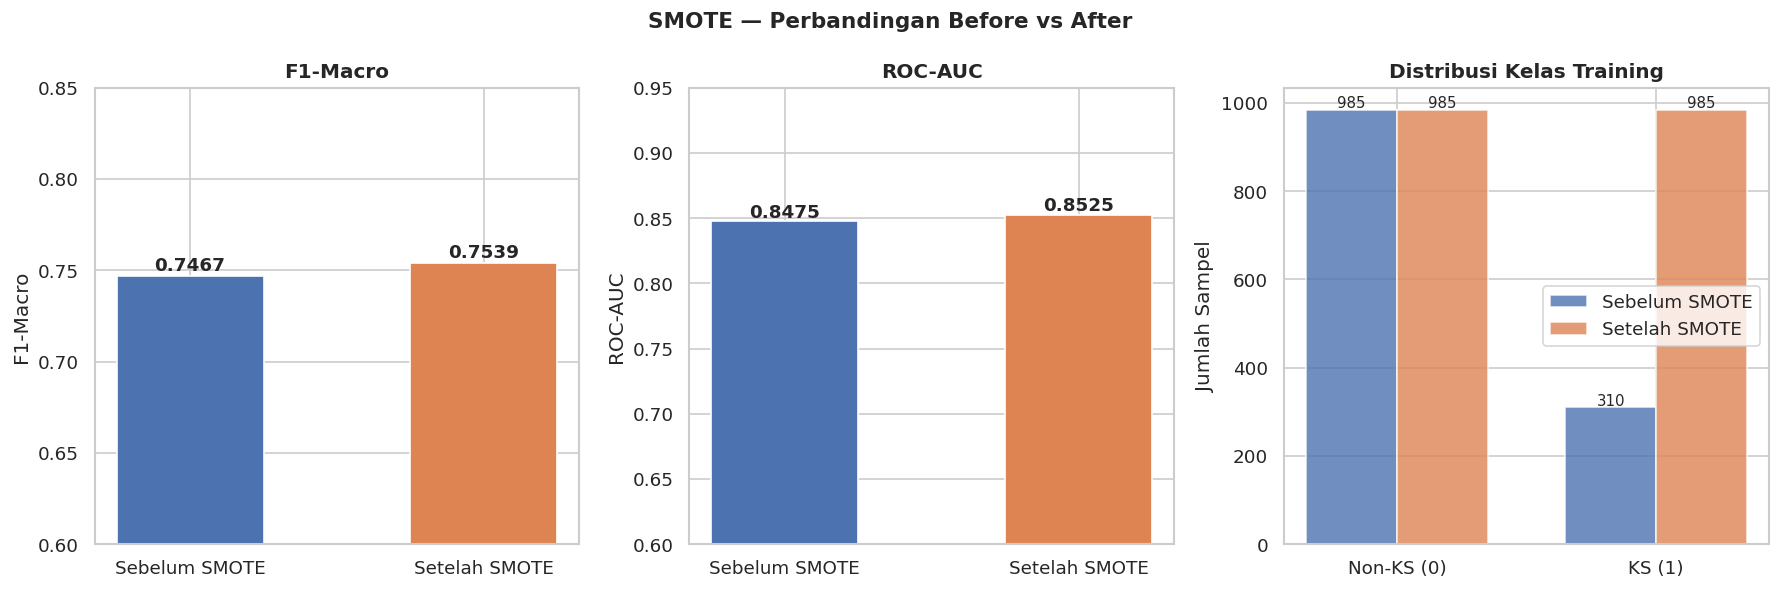

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C72B0', '#DD8452']

# F1-Macro before vs after
axes[0].bar(['Sebelum SMOTE', 'Setelah SMOTE'],
            [f1_before, f1_after], color=colors, width=0.5)
axes[0].set_title('F1-Macro', fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_ylim(0.6, 0.85)
for i, v in enumerate([f1_before, f1_after]):
    axes[0].text(i, v + 0.003, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

# ROC-AUC before vs after
axes[1].bar(['Sebelum SMOTE', 'Setelah SMOTE'],
            [auc_before, auc_after], color=colors, width=0.5)
axes[1].set_title('ROC-AUC', fontweight='bold')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.6, 0.95)
for i, v in enumerate([auc_before, auc_after]):
    axes[1].text(i, v + 0.003, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

# Distribusi kelas sebelum vs setelah SMOTE
before_dist = dict(zip(*np.unique(y_train, return_counts=True)))
x  = np.arange(2)
w  = 0.35
b1 = axes[2].bar(x - w/2,
                 [before_dist[0], before_dist[1]],
                 w, label='Sebelum SMOTE', color='#4C72B0', alpha=0.8)
b2 = axes[2].bar(x + w/2,
                 [dist_after[0], dist_after[1]],
                 w, label='Setelah SMOTE',  color='#DD8452', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Non-KS (0)', 'KS (1)'])
axes[2].set_title('Distribusi Kelas Training', fontweight='bold')
axes[2].set_ylabel('Jumlah Sampel')
axes[2].legend()
for bar in list(b1) + list(b2):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{int(bar.get_height())}',
                 ha='center', fontsize=9)

plt.suptitle('SMOTE — Perbandingan Before vs After',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_11_smote_comparison.png', bbox_inches='tight')
plt.show()

## Confusion Matrix Before vs After

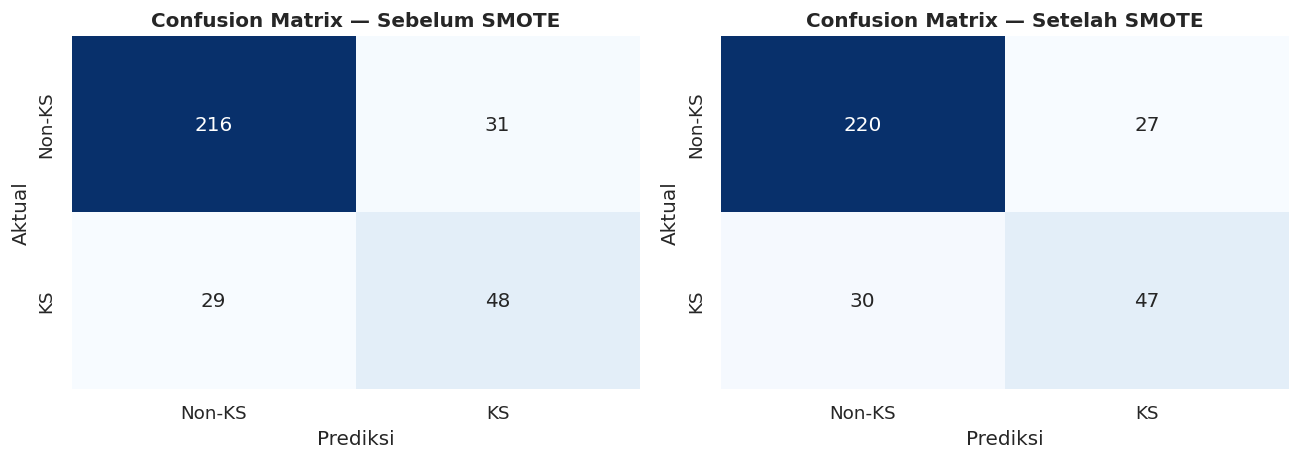

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_pred, title in [
    (axes[0], y_pred_before, 'Confusion Matrix — Sebelum SMOTE'),
    (axes[1], y_pred_after,  'Confusion Matrix — Setelah SMOTE'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-KS', 'KS'],
                yticklabels=['Non-KS', 'KS'],
                cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('plot_12_confusion_matrix_smote.png', bbox_inches='tight')
plt.show()

## Ringkasan Handling Imbalanced Data

In [ ]:
print("=" * 60)
print("RINGKASAN BLOCK 6 — SMOTE")
print("=" * 60)
print()
print(f"Imbalance ratio awal : 3.18:1")
print(f"Setelah SMOTE        : 1:1 (balanced)")
print()
print(f"F1-Macro  : {f1_before:.4f} → {f1_after:.4f} "
      f"({delta_f1:+.4f})")
print(f"ROC-AUC   : {auc_before:.4f} → {auc_after:.4f} "
      f"({delta_auc:+.4f})")
print()
if delta_f1 >= 0:
    print("→ SMOTE meningkatkan atau mempertahankan F1-Macro.")
else:
    print("→ SMOTE menurunkan F1-Macro tipis.")
    print("  Ini umum terjadi ketika class_weight='balanced' sudah")
    print("  menangani imbalance secara implisit di LR.")
    print("  SMOTE tetap penting untuk model yang tidak punya")
    print("  class_weight (BiLSTM-GRU).")
print()
print("Catatan penting:")
print("  SMOTE hanya diterapkan pada TRAINING SET.")
print("  Test set tetap menggunakan distribusi asli (imbalanced)")
print("  agar evaluasi mencerminkan kondisi nyata deployment.")
print()
print("=" * 60)

RINGKASAN BLOCK 6 — SMOTE

Imbalance ratio awal : 3.18:1
Setelah SMOTE        : 1:1 (balanced)

F1-Macro  : 0.7467 → 0.7539 (+0.0072)
ROC-AUC   : 0.8475 → 0.8525 (+0.0049)

→ SMOTE meningkatkan atau mempertahankan F1-Macro.

Catatan penting:
  SMOTE hanya diterapkan pada TRAINING SET.
  Test set tetap menggunakan distribusi asli (imbalanced)
  agar evaluasi mencerminkan kondisi nyata deployment.



# Hyperparameter Tuning: GridSearchCV

In [ ]:
import pandas as pd
import numpy as np
import time
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import time

print("✓ Library siap")

✓ Library siap


## Definisi Parameter Grid

In [ ]:
# Parameter grid untuk TF-IDF + Logistic Regression
# Tuning dilakukan pada baseline model karena:
# 1. GridSearch pada transformer (IndoBERT) prohibitively expensive
# 2. TF-IDF+LR adalah model yang paling interpretable untuk dioptimasi
# 3. Hasil tuning menjadi konfigurasi optimal yang dibandingkan
#    dengan default parameter

param_grid = {
    'C'          : [0.01, 0.1, 1, 10, 100],
    'solver'     : ['lbfgs', 'saga'],
    'max_iter'   : [500, 1000],
    'penalty'    : ['l2'],
}

# Hitung total kombinasi
total = (len(param_grid['C']) *
         len(param_grid['solver']) *
         len(param_grid['max_iter']) *
         len(param_grid['penalty']))

print("Parameter Grid:")
for k, v in param_grid.items():
    print(f"  {k:12} : {v}")
print()
print(f"Total kombinasi        : {total}")
print(f"CV folds               : 5")
print(f"Total model di-fit     : {total * 5}")
print()
print("Input: X_train_smote (SMOTE-balanced), y_train_smote")
print(f"  Shape: {X_train_smote.shape}")

Parameter Grid:
  C            : [0.01, 0.1, 1, 10, 100]
  solver       : ['lbfgs', 'saga']
  max_iter     : [500, 1000]
  penalty      : ['l2']

Total kombinasi        : 20
CV folds               : 5
Total model di-fit     : 100

Input: X_train_smote (SMOTE-balanced), y_train_smote
  Shape: (1970, 3030)


## Baseline Sebelum Tuning

In [ ]:
# ── Baseline sebelum tuning (pakai X_train asli, bukan SMOTE) ─
lr_default = LogisticRegression(
    class_weight='balanced',
    random_state=42
)
t0 = time.time()
lr_default.fit(X_train, y_train)   # X_train asli dari Block 4
t_default = time.time() - t0

y_pred_default = lr_default.predict(X_test)
f1_default     = f1_score(y_test, y_pred_default, average='macro')
auc_default    = roc_auc_score(
                     y_test, lr_default.predict_proba(X_test)[:, 1])

print("=" * 55)
print("BASELINE — Default Parameter (tanpa tuning)")
print("=" * 55)
print(f"F1-Macro  : {f1_default:.4f}")
print(f"ROC-AUC   : {auc_default:.4f}")
print(f"Waktu fit : {t_default:.3f} detik")

BASELINE — Default Parameter (tanpa tuning)
F1-Macro  : 0.7467
ROC-AUC   : 0.8475
Waktu fit : 0.142 detik


## Jalankan GridSearch

In [ ]:
# ── Pipeline: SMOTE di dalam fold ────────────────────────────
# Urutan yang benar:
#   1. Split fold (CV)
#   2. SMOTE pada training fold saja
#   3. Fit model pada training fold yang sudah balanced
#   4. Evaluasi pada validation fold (data asli, tidak di-SMOTE)

pipeline = ImbPipeline([
    ('smote', SMOTE(k_neighbors=5, random_state=42)),
    ('lr',    LogisticRegression(
                  class_weight='balanced',
                  random_state=42))
])

# Parameter grid — prefix 'lr__' karena dalam pipeline
param_grid = {
    'lr__C'       : [0.01, 0.1, 1, 10, 100],
    'lr__solver'  : ['lbfgs', 'saga'],
    'lr__max_iter': [500, 1000],
    'lr__penalty' : ['l2'],
}

total = (len(param_grid['lr__C']) *
         len(param_grid['lr__solver']) *
         len(param_grid['lr__max_iter']) *
         len(param_grid['lr__penalty']))

print(f"Total kombinasi : {total} x 5 folds = {total*5} fits")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Menjalankan GridSearchCV dengan pipeline SMOTE-in-fold...")
print("Estimasi waktu: 5-10 menit")

t0 = time.time()
grid_search.fit(X_train, y_train)   # X_train ASLI — SMOTE ada di dalam pipeline
t_grid = time.time() - t0

print(f"\n✓ Selesai dalam {t_grid:.1f} detik")

Total kombinasi : 20 x 5 folds = 100 fits
Menjalankan GridSearchCV dengan pipeline SMOTE-in-fold...
Estimasi waktu: 5-10 menit
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Selesai dalam 40.4 detik


## Hasil GridSearch

In [ ]:
# ── Hasil GridSearch ──────────────────────────────────────────
best_params_clean = {
    k.replace('lr__', ''): v
    for k, v in grid_search.best_params_.items()
}

print("=" * 55)
print("HASIL GRIDSEARCHCV (Pipeline)")
print("=" * 55)
print("Parameter terbaik:")
for k, v in best_params_clean.items():
    print(f"  {k:12} : {v}")
print(f"\nBest CV F1-Macro : {grid_search.best_score_:.4f}")

HASIL GRIDSEARCHCV (Pipeline)
Parameter terbaik:
  C            : 1
  max_iter     : 500
  penalty      : l2
  solver       : saga

Best CV F1-Macro : 0.7152


## Evaluasi Model Optimal pada Test Set

In [ ]:
# ── Evaluasi pada test set ────────────────────────────────────
best_model   = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

f1_tuned  = f1_score(y_test, y_pred_tuned, average='macro')
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("=" * 55)
print("EVALUASI TEST SET — Parameter Optimal")
print("=" * 55)
print(f"F1-Macro  : {f1_tuned:.4f}")
print(f"ROC-AUC   : {auc_tuned:.4f}")
print()
print(classification_report(y_test, y_pred_tuned,
      target_names=['Non-KS', 'KS']))

EVALUASI TEST SET — Parameter Optimal
F1-Macro  : 0.7539
ROC-AUC   : 0.8526

              precision    recall  f1-score   support

      Non-KS       0.88      0.89      0.89       247
          KS       0.64      0.61      0.62        77

    accuracy                           0.82       324
   macro avg       0.76      0.75      0.75       324
weighted avg       0.82      0.82      0.82       324



## Perbandingan

In [ ]:
# ── Tabel perbandingan + computational cost ───────────────────
delta_f1  = f1_tuned  - f1_default
delta_auc = auc_tuned - auc_default

results_tuning = pd.DataFrame([
    {
        'Konfigurasi'         : 'Default Parameter',
        'F1-Macro (test)'     : round(f1_default, 4),
        'ROC-AUC (test)'      : round(auc_default, 4),
        'Waktu (s)'           : round(t_default, 3),
        'Keterangan'          : 'Single fit',
    },
    {
        'Konfigurasi'         : 'Optimal (GridSearch)',
        'F1-Macro (test)'     : round(f1_tuned, 4),
        'ROC-AUC (test)'      : round(auc_tuned, 4),
        'Waktu (s)'           : round(t_grid, 1),
        'Keterangan'          : f'{total*5} fits',
    },
])

print("=" * 70)
print("PERBANDINGAN DEFAULT vs OPTIMAL + COMPUTATIONAL COST")
print("=" * 70)
print(results_tuning.to_string(index=False))
print()
print(f"ΔF1-Macro  : {delta_f1:+.4f}")
print(f"ΔROC-AUC   : {delta_auc:+.4f}")
print(f"Overhead   : {t_grid:.1f} detik untuk {total*5} model fits")

results_tuning.to_csv('gridsearch_results.csv', index=False)

PERBANDINGAN DEFAULT vs OPTIMAL + COMPUTATIONAL COST
         Konfigurasi  F1-Macro (test)  ROC-AUC (test)  Waktu (s) Keterangan
   Default Parameter           0.7467          0.8475      0.142 Single fit
Optimal (GridSearch)           0.7539          0.8526     40.400   100 fits

ΔF1-Macro  : +0.0072
ΔROC-AUC   : +0.0050
Overhead   : 40.4 detik untuk 100 model fits


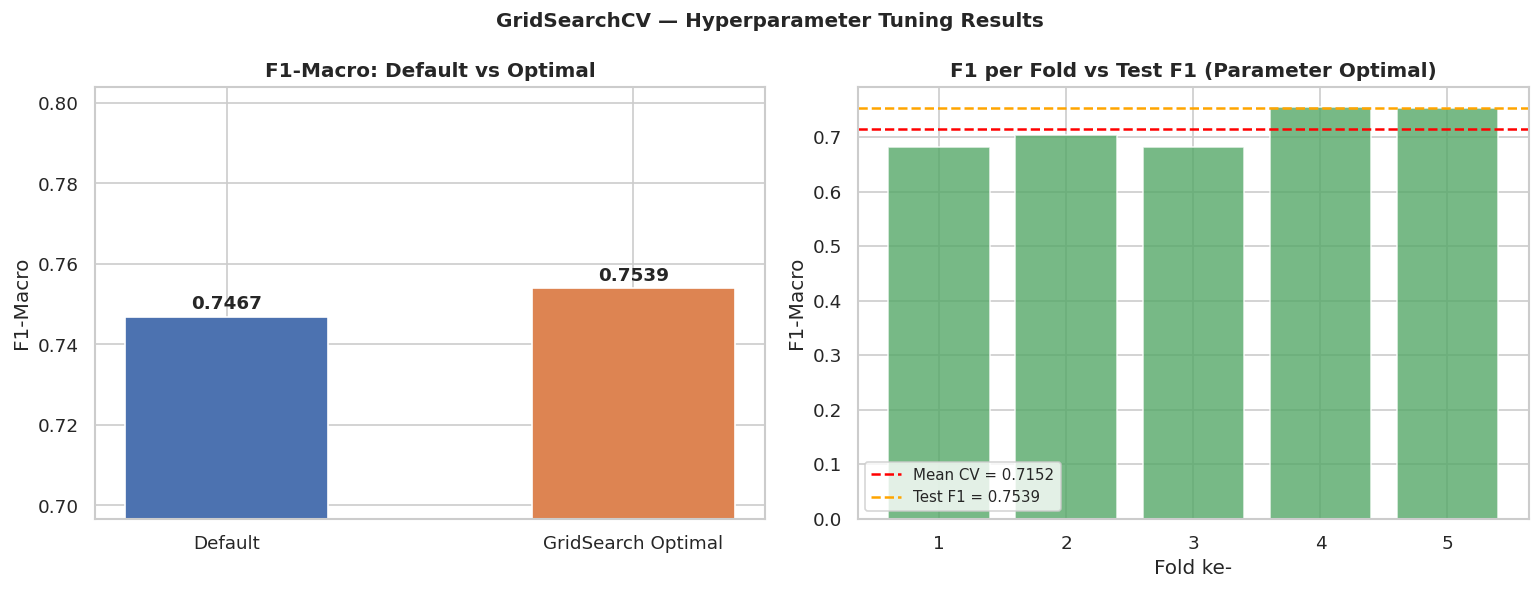

In [ ]:
# ── Plot ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4C72B0', '#DD8452']

# F1 comparison
axes[0].bar(['Default', 'GridSearch Optimal'],
            [f1_default, f1_tuned], color=colors, width=0.5)
axes[0].set_title('F1-Macro: Default vs Optimal', fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_ylim(max(0, min(f1_default, f1_tuned) - 0.05),
                 max(f1_default, f1_tuned) + 0.05)
for i, v in enumerate([f1_default, f1_tuned]):
    axes[0].text(i, v + 0.002, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

# CV scores per fold untuk parameter optimal
cv_results = pd.DataFrame(grid_search.cv_results_)
best_idx   = grid_search.best_index_
fold_scores = [
    cv_results[f'split{i}_test_score'].iloc[best_idx]
    for i in range(5)
]
axes[1].bar(range(1, 6), fold_scores, color='#55A868', alpha=0.8)
axes[1].axhline(y=np.mean(fold_scores), color='red',
                linestyle='--', linewidth=1.5,
                label=f'Mean CV = {np.mean(fold_scores):.4f}')
axes[1].axhline(y=f1_tuned, color='orange',
                linestyle='--', linewidth=1.5,
                label=f'Test F1 = {f1_tuned:.4f}')
axes[1].set_title('F1 per Fold vs Test F1 (Parameter Optimal)',
                  fontweight='bold')
axes[1].set_xlabel('Fold ke-')
axes[1].set_ylabel('F1-Macro')
axes[1].set_xticks(range(1, 6))
axes[1].legend(fontsize=9)

plt.suptitle('GridSearchCV — Hyperparameter Tuning Results',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_13_gridsearch.png', bbox_inches='tight')
plt.show()

## Simpan Model & Ringkasan

In [ ]:
# ── Simpan & ringkasan ────────────────────────────────────────
import joblib
joblib.dump(best_model, 'lr_optimal.pkl')

print("=" * 60)
print("RINGKASAN BLOCK 7 — GRIDSEARCHCV (Pipeline)")
print("=" * 60)
print()
print("Perbaikan metodologis dari iterasi sebelumnya:")
print("  SMOTE sekarang diterapkan DI DALAM setiap fold CV")
print("  menggunakan imblearn.Pipeline — mencegah data leakage")
print("  dari sampel sintetis ke validation fold.")
print()
print(f"Total kombinasi     : {total} x 5 folds = {total*5} fits")
print(f"Waktu GridSearch    : {t_grid:.1f} detik")
print()
print(f"Default  → F1={f1_default:.4f}")
print(f"Optimal  → F1={f1_tuned:.4f}  ({delta_f1:+.4f})")
print()
print("Parameter optimal:")
for k, v in best_params_clean.items():
    print(f"  {k:12} : {v}")
print()
print("✓ Model optimal disimpan: lr_optimal.pkl")
print()
print("=" * 60)
print("BLOCK 7 SELESAI")
print("Next : Block 8 — K-Fold Cross Validation (Soal 3b)")
print("=" * 60)

RINGKASAN BLOCK 7 — GRIDSEARCHCV (Pipeline)

Perbaikan metodologis dari iterasi sebelumnya:
  SMOTE sekarang diterapkan DI DALAM setiap fold CV
  menggunakan imblearn.Pipeline — mencegah data leakage
  dari sampel sintetis ke validation fold.

Total kombinasi     : 20 x 5 folds = 100 fits
Waktu GridSearch    : 40.4 detik

Default  → F1=0.7467
Optimal  → F1=0.7539  (+0.0072)

Parameter optimal:
  C            : 1
  max_iter     : 500
  penalty      : l2
  solver       : saga

✓ Model optimal disimpan: lr_optimal.pkl

BLOCK 7 SELESAI
Next : Block 8 — K-Fold Cross Validation (Soal 3b)


# Stratified K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time

print("✓ Library siap")

✓ Library siap


## Setup K-Fold

In [ ]:
# Stratified K-Fold memastikan proporsi kelas dipertahankan
# di setiap fold — kritis untuk dataset imbalanced
# k=5 adalah standar umum: bias-variance trade-off yang baik
# untuk dataset ukuran sedang (~1600 sampel)

K = 5
cv = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# Scorer
f1_macro_scorer = make_scorer(f1_score, average='macro')

print(f"K-Fold strategy  : Stratified K-Fold")
print(f"K                : {K}")
print(f"Shuffle          : True (random_state=42)")
print(f"Scoring          : F1-Macro")
print(f"Dataset          : {X_full.shape[0]} sampel, {X_full.shape[1]} fitur")
print()
print("Distribusi kelas:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c} ({c/len(y)*100:.1f}%)")

K-Fold strategy  : Stratified K-Fold
K                : 5
Shuffle          : True (random_state=42)
Scoring          : F1-Macro
Dataset          : 1619 sampel, 3030 fitur

Distribusi kelas:
  Label 0: 1232 (76.1%)
  Label 1: 387 (23.9%)


## K-Fold: Model 1 (TF-IDF + LR Default)

In [ ]:
# Model 1: TF-IDF + LR dengan parameter DEFAULT
# Pipeline SMOTE-in-fold untuk konsistensi metodologis

pipeline_default = ImbPipeline([
    ('smote', SMOTE(k_neighbors=5, random_state=42)),
    ('lr',    LogisticRegression(
                  C=1.0,
                  solver='lbfgs',
                  max_iter=100,
                  penalty='l2',
                  class_weight='balanced',
                  random_state=42))
])

print("Menjalankan K-Fold untuk TF-IDF + LR Default...")
t0 = time.time()
scores_default = cross_validate(
    pipeline_default, X_full, y,
    cv=cv,
    scoring=f1_macro_scorer,
    return_train_score=True,
    n_jobs=-1
)
t_default = time.time() - t0

print(f"✓ Selesai dalam {t_default:.1f} detik")
print()
print("F1-Macro per fold:")
for i, (tr, te) in enumerate(zip(scores_default['train_score'],
                                   scores_default['test_score'])):
    print(f"  Fold {i+1}: train={tr:.4f} | val={te:.4f}")
print()
print(f"Mean Val F1  : {scores_default['test_score'].mean():.4f}")
print(f"Std Val F1   : {scores_default['test_score'].std():.4f}")

Menjalankan K-Fold untuk TF-IDF + LR Default...
✓ Selesai dalam 0.3 detik

F1-Macro per fold:
  Fold 1: train=0.9002 | val=0.7052
  Fold 2: train=0.9032 | val=0.7436
  Fold 3: train=0.9026 | val=0.7268
  Fold 4: train=0.9010 | val=0.7467
  Fold 5: train=0.9037 | val=0.7221

Mean Val F1  : 0.7289
Std Val F1   : 0.0151


## K-Fold: Model 2 (TF-IDF + LR Optimal)

In [ ]:
# Model 2: TF-IDF + LR dengan parameter OPTIMAL dari GridSearch
# C=1, solver=saga, max_iter=500, penalty=l2

pipeline_optimal = ImbPipeline([
    ('smote', SMOTE(k_neighbors=5, random_state=42)),
    ('lr',    LogisticRegression(
                  C=1,
                  solver='saga',
                  max_iter=500,
                  penalty='l2',
                  class_weight='balanced',
                  random_state=42))
])

print("Menjalankan K-Fold untuk TF-IDF + LR Optimal...")
t0 = time.time()
scores_optimal = cross_validate(
    pipeline_optimal, X_full, y,
    cv=cv,
    scoring=f1_macro_scorer,
    return_train_score=True,
    n_jobs=-1
)
t_optimal = time.time() - t0

print(f"✓ Selesai dalam {t_optimal:.1f} detik")
print()
print("F1-Macro per fold:")
for i, (tr, te) in enumerate(zip(scores_optimal['train_score'],
                                   scores_optimal['test_score'])):
    print(f"  Fold {i+1}: train={tr:.4f} | val={te:.4f}")
print()
print(f"Mean Val F1  : {scores_optimal['test_score'].mean():.4f}")
print(f"Std Val F1   : {scores_optimal['test_score'].std():.4f}")

Menjalankan K-Fold untuk TF-IDF + LR Optimal...
✓ Selesai dalam 1.6 detik

F1-Macro per fold:
  Fold 1: train=0.9011 | val=0.7023
  Fold 2: train=0.9032 | val=0.7436
  Fold 3: train=0.9026 | val=0.7208
  Fold 4: train=0.9010 | val=0.7467
  Fold 5: train=0.9039 | val=0.7221

Mean Val F1  : 0.7271
Std Val F1   : 0.0164


## Tabel Perbandingan per Fold

In [ ]:
fold_df = pd.DataFrame({
    'Fold'                    : [f'Fold {i+1}' for i in range(K)],
    'LR Default (val F1)'     : scores_default['test_score'].round(4),
    'LR Optimal (val F1)'     : scores_optimal['test_score'].round(4),
})

# Tambah baris mean dan std
fold_df.loc[len(fold_df)] = [
    'Mean ± Std',
    f"{scores_default['test_score'].mean():.4f} "
    f"± {scores_default['test_score'].std():.4f}",
    f"{scores_optimal['test_score'].mean():.4f} "
    f"± {scores_optimal['test_score'].std():.4f}",
]

print("=" * 60)
print("K-FOLD CROSS VALIDATION — HASIL PER FOLD")
print("=" * 60)
print(fold_df.to_string(index=False))

K-FOLD CROSS VALIDATION — HASIL PER FOLD
      Fold LR Default (val F1) LR Optimal (val F1)
    Fold 1              0.7052              0.7023
    Fold 2              0.7436              0.7436
    Fold 3              0.7268              0.7208
    Fold 4              0.7467              0.7467
    Fold 5              0.7221              0.7221
Mean ± Std     0.7289 ± 0.0151     0.7271 ± 0.0164


## Analisis Stabilitas

In [ ]:
print("=" * 60)
print("ANALISIS STABILITAS MODEL")
print("=" * 60)
print()

for nama, scores in [('LR Default', scores_default['test_score']),
                      ('LR Optimal', scores_optimal['test_score'])]:
    mean = scores.mean()
    std  = scores.std()
    cv_  = std / mean  # Coefficient of variation
    rng  = scores.max() - scores.min()

    print(f"{nama}:")
    print(f"  Mean F1     : {mean:.4f}")
    print(f"  Std         : {std:.4f}")
    print(f"  Range       : {rng:.4f} (max-min)")
    print(f"  CV (std/mean): {cv_:.4f}")
    stabil = "Stabil" if std < 0.02 else "Kurang stabil"
    print(f"  Status      : {stabil}")
    print()

ANALISIS STABILITAS MODEL

LR Default:
  Mean F1     : 0.7289
  Std         : 0.0151
  Range       : 0.0415 (max-min)
  CV (std/mean): 0.0207
  Status      : Stabil

LR Optimal:
  Mean F1     : 0.7271
  Std         : 0.0164
  Range       : 0.0444 (max-min)
  CV (std/mean): 0.0225
  Status      : Stabil



/tmp/ipykernel_2151/694860446.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


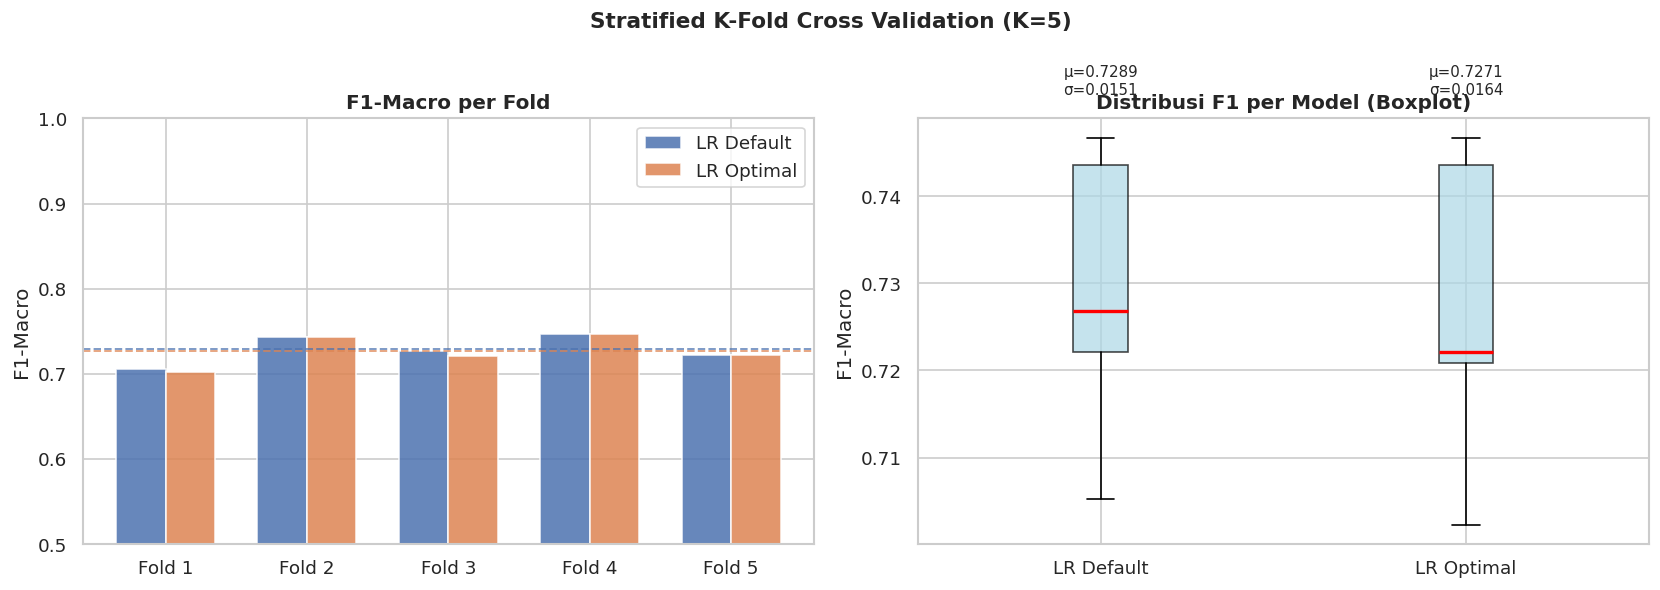

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds  = [f'Fold {i+1}' for i in range(K)]
x      = np.arange(K)
width  = 0.35
colors = ['#4C72B0', '#DD8452']

# Per-fold comparison
axes[0].bar(x - width/2, scores_default['test_score'],
            width, label='LR Default', color=colors[0], alpha=0.85)
axes[0].bar(x + width/2, scores_optimal['test_score'],
            width, label='LR Optimal', color=colors[1], alpha=0.85)
axes[0].axhline(y=scores_default['test_score'].mean(),
                color=colors[0], linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].axhline(y=scores_optimal['test_score'].mean(),
                color=colors[1], linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(folds)
axes[0].set_ylabel('F1-Macro')
axes[0].set_title('F1-Macro per Fold', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)

# Boxplot stabilitas
axes[1].boxplot(
    [scores_default['test_score'], scores_optimal['test_score']],
    labels=['LR Default', 'LR Optimal'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_ylabel('F1-Macro')
axes[1].set_title('Distribusi F1 per Model (Boxplot)', fontweight='bold')

# Annotasi mean
for i, scores in enumerate([scores_default['test_score'],
                              scores_optimal['test_score']], 1):
    axes[1].text(i, scores.max() + 0.005,
                 f'μ={scores.mean():.4f}\nσ={scores.std():.4f}',
                 ha='center', fontsize=9)

plt.suptitle('Stratified K-Fold Cross Validation (K=5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_14_kfold.png', bbox_inches='tight')
plt.show()

## Ringkasan

In [ ]:
print("=" * 60)
print("RINGKASAN BLOCK 8 — STRATIFIED K-FOLD CV")
print("=" * 60)
print()
print(f"Metode     : Stratified K-Fold (K={K})")
print(f"Dataset    : {X_full.shape[0]} sampel")
print(f"Strategi   : SMOTE di dalam setiap fold (via Pipeline)")
print()
print("Hasil:")
print(f"  LR Default : {scores_default['test_score'].mean():.4f} "
      f"± {scores_default['test_score'].std():.4f}")
print(f"  LR Optimal : {scores_optimal['test_score'].mean():.4f} "
      f"± {scores_optimal['test_score'].std():.4f}")
print()

delta = scores_optimal['test_score'].mean() - scores_default['test_score'].mean()
print(f"Peningkatan mean F1 dari tuning : {delta:+.4f}")
print()

# Cek overfitting: gap train vs val
gap_default = (scores_default['train_score'].mean() -
               scores_default['test_score'].mean())
gap_optimal = (scores_optimal['train_score'].mean() -
               scores_optimal['test_score'].mean())
print(f"Train-Val gap (Default) : {gap_default:.4f}")
print(f"Train-Val gap (Optimal) : {gap_optimal:.4f}")
print()
print("=" * 60)
print("BLOCK 8 SELESAI")
print("Next : Block 9 — Evaluasi Final Ketiga Model")
print("=" * 60)

RINGKASAN BLOCK 8 — STRATIFIED K-FOLD CV

Metode     : Stratified K-Fold (K=5)
Dataset    : 1619 sampel
Strategi   : SMOTE di dalam setiap fold (via Pipeline)

Hasil:
  LR Default : 0.7289 ± 0.0151
  LR Optimal : 0.7271 ± 0.0164

Peningkatan mean F1 dari tuning : -0.0018

Train-Val gap (Default) : 0.1732
Train-Val gap (Optimal) : 0.1753

BLOCK 8 SELESAI
Next : Block 9 — Evaluasi Final Ketiga Model


# BiLSTM-GRU

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM,
                                      GRU, Dropout, Dense, SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import time

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
GPU available      : True


In [ ]:
df = pd.read_csv('dataset_preprocessed.csv')

print(f"Shape  : {df.shape}")
print(f"Label  : {df['Label'].value_counts().sort_index().to_dict()}")

# Train/test split — stratified, konsisten dengan Block sebelumnya
X_text = df['full_text_clean'].astype(str).values
y      = df['Label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain : {len(X_train_text)} sampel")
print(f"Test  : {len(X_test_text)} sampel")
print(f"Train dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test dist : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Shape  : (1619, 2)
Label  : {0: 1232, 1: 387}

Train : 1295 sampel
Test  : 324 sampel
Train dist: {np.int64(0): np.int64(985), np.int64(1): np.int64(310)}
Test dist : {np.int64(0): np.int64(247), np.int64(1): np.int64(77)}


## Tokenisasi & Padding

In [ ]:
VOCAB_SIZE  = 8000
MAX_LEN     = 30      # Turun dari 50 → P90 panjang teks adalah 28
OOV_TOKEN   = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f"MAX_LEN       : {MAX_LEN}")
print(f"X_train_pad   : {X_train_pad.shape}")
print(f"X_test_pad    : {X_test_pad.shape}")

MAX_LEN       : 30
X_train_pad   : (1295, 30)
X_test_pad    : (324, 30)


##  Class Weight (menangani imbalance)

In [ ]:
# Class weight sebagai alternatif SMOTE untuk Keras
# SMOTE tidak bisa langsung dipakai di Keras training loop
# class_weight='balanced' setara dengan weighted loss per sampel

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for k, v in class_weight_dict.items():
    label = 'Non-KS' if k == 0 else 'KS'
    print(f"  Label {k} ({label}): {v:.4f}")
print()
print("→ Label KS diberi bobot lebih tinggi karena jumlahnya lebih sedikit")

Class weights:
  Label 0 (Non-KS): 0.6574
  Label 1 (KS): 2.0887

→ Label KS diberi bobot lebih tinggi karena jumlahnya lebih sedikit


## Arsitektur BiLSTM-GRU

In [ ]:
EMBEDDING_DIM = 128
BILSTM_UNITS  = 64
GRU_UNITS     = 64
DROPOUT_RATE  = 0.4   # Turun dari 0.5

def build_bilstm_gru(vocab_size, embedding_dim, max_len,
                      bilstm_units, gru_units, dropout_rate):
    model = Sequential([
        Embedding(input_dim=vocab_size + 1,
                  output_dim=embedding_dim,
                  input_length=max_len,
                  name='embedding'),

        SpatialDropout1D(rate=0.2, name='spatial_dropout'),

        Bidirectional(
            LSTM(units=bilstm_units,
                 return_sequences=True,
                 recurrent_dropout=0.1),
            name='bilstm'
        ),

        GRU(units=gru_units,
            return_sequences=False,
            recurrent_dropout=0.1,
            name='gru'),

        Dropout(rate=dropout_rate, name='dropout'),

        Dense(1, activation='sigmoid', name='output')
    ])
    return model

model_bilstm = build_bilstm_gru(
    vocab_size    = VOCAB_SIZE,
    embedding_dim = EMBEDDING_DIM,
    max_len       = MAX_LEN,
    bilstm_units  = BILSTM_UNITS,
    gru_units     = GRU_UNITS,
    dropout_rate  = DROPOUT_RATE
)

# Learning rate dikecilkan — ini fix utama untuk oscillation
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

model_bilstm.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bilstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training BiLSTM-GRU

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,            # Naik dari 3 → beri lebih banyak kesempatan
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Retraining BiLSTM-GRU (fixed hyperparameters)...")
print(f"  Learning rate : 3e-4")
print(f"  MAX_LEN       : {MAX_LEN}")
print(f"  Batch size    : 64")
print(f"  Dropout       : {DROPOUT_RATE}")
print()

t0 = time.time()
history = model_bilstm.fit(
    X_train_pad, y_train,
    epochs=30,             # Naik dari 20 → EarlyStopping yang kontrol
    batch_size=64,         # Naik dari 32 → gradient lebih stabil
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
t_bilstm = time.time() - t0

print(f"\n✓ Selesai dalam {t_bilstm:.1f} detik")
print(f"  Epoch berhenti di : {len(history.history['loss'])}")

Retraining BiLSTM-GRU (fixed hyperparameters)...
  Learning rate : 3e-4
  MAX_LEN       : 30
  Batch size    : 64
  Dropout       : 0.4

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 743ms/step - accuracy: 0.3116 - loss: 0.6927 - val_accuracy: 0.2846 - val_loss: 0.7108 - learning_rate: 3.0000e-04
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 289ms/step - accuracy: 0.3296 - loss: 0.6916 - val_accuracy: 0.3000 - val_loss: 0.7030 - learning_rate: 3.0000e-04
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.4936 - loss: 0.6909 - val_accuracy: 0.4462 - val_loss: 0.6908 - learning_rate: 3.0000e-04
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step - accuracy: 0.4223 - loss: 0.6885 - val_accuracy: 0.3615 - val_loss: 0.7004 - learning_rate: 3.0000e-04
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step - accuracy: 0.4481 - loss: 0.6820 - val_accuracy: 0.5846 - val_loss: 0.6695 - learning_rate: 3.0000e-04
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - accuracy: 0.6644 - loss: 0

## Evaluasi BiLSTM-GRU

In [ ]:
# Prediksi
y_prob_bilstm = model_bilstm.predict(X_test_pad, verbose=0).flatten()
y_pred_bilstm = (y_prob_bilstm >= 0.5).astype(int)

f1_bilstm  = f1_score(y_test, y_pred_bilstm, average='macro')
auc_bilstm = roc_auc_score(y_test, y_prob_bilstm)

print("=" * 55)
print("EVALUASI BiLSTM-GRU — Test Set")
print("=" * 55)
print(f"F1-Macro  : {f1_bilstm:.4f}")
print(f"ROC-AUC   : {auc_bilstm:.4f}")
print()
print(classification_report(y_test, y_pred_bilstm,
      target_names=['Non-KS', 'KS']))

EVALUASI BiLSTM-GRU — Test Set
F1-Macro  : 0.6571
ROC-AUC   : 0.7672

              precision    recall  f1-score   support

      Non-KS       0.84      0.81      0.83       247
          KS       0.46      0.52      0.49        77

    accuracy                           0.74       324
   macro avg       0.65      0.66      0.66       324
weighted avg       0.75      0.74      0.75       324



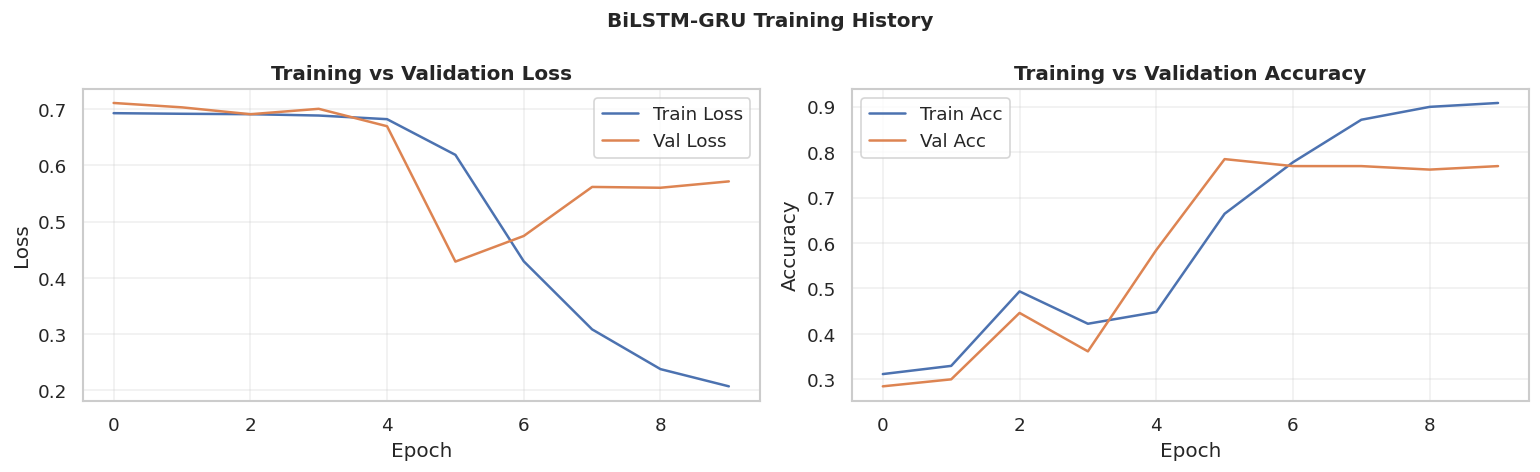

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#4C72B0')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#DD8452')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Acc', color='#4C72B0')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='#DD8452')
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('BiLSTM-GRU Training History', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_15_bilstm_history.png', bbox_inches='tight')
plt.show()

##  Simpan Model & Hasil

In [ ]:
import joblib

# Simpan model dan tokenizer
model_bilstm.save('model_bilstm_gru.h5')
joblib.dump(tokenizer, 'tokenizer_bilstm.pkl')

# Simpan hasil untuk evaluasi final
bilstm_results = {
    'model'    : 'BiLSTM-GRU',
    'f1_macro' : round(f1_bilstm, 4),
    'roc_auc'  : round(auc_bilstm, 4),
    'waktu_s'  : round(t_bilstm, 1),
    'epochs'   : len(history.history['loss']),
}

print("=" * 55)
print("RINGKASAN BiLSTM-GRU")
print("=" * 55)
print(f"F1-Macro  : {f1_bilstm:.4f}")
print(f"ROC-AUC   : {auc_bilstm:.4f}")
print(f"Waktu     : {t_bilstm:.1f} detik")
print(f"Epochs    : {len(history.history['loss'])}")
print()
print("✓ Model disimpan: model_bilstm_gru.h5")
print("✓ Tokenizer disimpan: tokenizer_bilstm.pkl")
print()
print("Next: Block 9B — IndoBERT")

RINGKASAN BiLSTM-GRU
F1-Macro  : 0.6571
ROC-AUC   : 0.7672
Waktu     : 118.2 detik
Epochs    : 10

✓ Model disimpan: model_bilstm_gru.h5
✓ Tokenizer disimpan: tokenizer_bilstm.pkl

Next: Block 9B — IndoBERT


# IndoBERT Fine-tuning

In [ ]:
!pip install transformers datasets --quiet

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, roc_auc_score
import time

# Cek GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Torch  : {torch.__version__}")

Device : cuda
GPU    : Tesla T4
Torch  : 2.11.0+cu128


## Load Data & Split

In [ ]:
df = pd.read_csv('dataset_preprocessed.csv')

X_text = df['full_text_clean'].astype(str).values
y      = df['Label'].values

# Split konsisten dengan semua block sebelumnya
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Validasi split dari train untuk IndoBERT
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_text, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Train : {len(X_train_text)} sampel")
print(f"Val   : {len(X_val_text)} sampel")
print(f"Test  : {len(X_test_text)} sampel")
print(f"Train dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Train : 1165 sampel
Val   : 130 sampel
Test  : 324 sampel
Train dist: {np.int64(0): np.int64(886), np.int64(1): np.int64(279)}


## Load IndoBERT Tokenizer

In [ ]:
# IndoBERT: model BERT pre-trained untuk Bahasa Indonesia
# Dikembangkan oleh IndoNLP (Koto et al., 2020)
# Dilatih pada dataset Indonesian Wikipedia + news corpus

MODEL_NAME = 'indobenchmark/indobert-base-p2'

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✓ Tokenizer berhasil dimuat")
print(f"  Vocab size: {tokenizer_bert.vocab_size}")

Loading tokenizer: indobenchmark/indobert-base-p2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Tokenizer berhasil dimuat
  Vocab size: 30521


## Load Model IndoBERT

In [ ]:
print(f"Loading model: {MODEL_NAME}")
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)
model_bert = model_bert.to(device)
print("✓ Model berhasil dimuat")
print(f"  Parameters: {sum(p.numel() for p in model_bert.parameters()):,}")

Loading model: indobenchmark/indobert-base-p2


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model berhasil dimuat
  Parameters: 124,442,882


## Dataset Class (PyTorch)

In [ ]:
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch

class TweetDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }

MAX_LEN_BERT = 128
BATCH_SIZE   = 16

train_dataset = TweetDataset(X_train_text, y_train, tokenizer_bert, MAX_LEN_BERT)
val_dataset   = TweetDataset(X_val_text,   y_val,   tokenizer_bert, MAX_LEN_BERT)
test_dataset  = TweetDataset(X_test_text,  y_test,  tokenizer_bert, MAX_LEN_BERT)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Class weights
n_0 = (y_train == 0).sum()
n_1 = (y_train == 1).sum()
total = len(y_train)
weights = torch.tensor(
    [total/(2*n_0), total/(2*n_1)],
    dtype=torch.float
).to(device)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Class weights : Non-KS={weights[0]:.4f}, KS={weights[1]:.4f}")
print("✓ DataLoader siap")

Train batches : 73
Val batches   : 5
Class weights : Non-KS=0.6574, KS=2.0878
✓ DataLoader siap


## Setup Optimizer & Scheduler

In [ ]:
EPOCHS    = 5
LR        = 2e-5

optimizer = AdamW(model_bert.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

loss_fn = CrossEntropyLoss(weight=weights)

print(f"Epochs        : {EPOCHS}")
print(f"Learning rate : {LR}")
print(f"Total steps   : {total_steps}")
print(f"Warmup steps  : {warmup_steps}")
print("✓ Optimizer & scheduler siap")

Epochs        : 5
Learning rate : 2e-05
Total steps   : 365
Warmup steps  : 36
✓ Optimizer & scheduler siap


## Training Loop

In [ ]:
def evaluate(model, loader, loss_fn, device):
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)
            outputs   = model(input_ids=input_ids,
                              attention_mask=attn_mask)
            loss      = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1

print("Fine-tuning IndoBERT...")
print(f"  Device : {device}")
print(f"  Epochs : {EPOCHS}")
print()

best_val_f1    = 0
best_epoch     = 0
train_history  = []
patience_count = 0
PATIENCE       = 2

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────
    model_bert.train()
    train_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model_bert(input_ids=input_ids,
                             attention_mask=attn_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        # Gradient clipping — mencegah exploding gradients
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)

        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ── Validation ────────────────────────────────────────────
    val_loss, val_f1 = evaluate(model_bert, val_loader, loss_fn, device)

    train_history.append({
        'epoch'     : epoch,
        'train_loss': round(avg_train_loss, 4),
        'val_loss'  : round(val_loss, 4),
        'val_f1'    : round(val_f1, 4),
    })

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss={avg_train_loss:.4f} | "
          f"Val Loss={val_loss:.4f} | "
          f"Val F1={val_f1:.4f}")

    # ── Early stopping & simpan model terbaik ─────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save(model_bert.state_dict(), 'indobert_best.pt')
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping di epoch {epoch}")
            break

t_bert = time.time() - t0

# Load model terbaik
model_bert.load_state_dict(torch.load('indobert_best.pt'))

print(f"\n✓ Training selesai dalam {t_bert:.1f} detik "
      f"({t_bert/60:.1f} menit)")
print(f"  Best epoch : {best_epoch} (Val F1={best_val_f1:.4f})")

Fine-tuning IndoBERT...
  Device : cuda
  Epochs : 5



model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Epoch 1/5 | Train Loss=0.6182 | Val Loss=0.4142 | Val F1=0.7211
Epoch 2/5 | Train Loss=0.3841 | Val Loss=0.4430 | Val F1=0.7688
Epoch 3/5 | Train Loss=0.2301 | Val Loss=0.7328 | Val F1=0.7348
Epoch 4/5 | Train Loss=0.1199 | Val Loss=0.8090 | Val F1=0.7641

Early stopping di epoch 4

✓ Training selesai dalam 126.8 detik (2.1 menit)
  Best epoch : 2 (Val F1=0.7688)


## Evaluasi IndoBERT

In [ ]:
print("Evaluasi pada test set...")

model_bert.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)
        outputs   = model_bert(input_ids=input_ids,
                               attention_mask=attn_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_pred_bert = np.array(all_preds)
y_prob_bert = np.array(all_probs)

f1_bert  = f1_score(all_labels, y_pred_bert, average='macro')
auc_bert = roc_auc_score(all_labels, y_prob_bert)

print("=" * 55)
print("EVALUASI IndoBERT — Test Set")
print("=" * 55)
print(f"F1-Macro  : {f1_bert:.4f}")
print(f"ROC-AUC   : {auc_bert:.4f}")
print()
print(classification_report(all_labels, y_pred_bert,
      target_names=['Non-KS', 'KS']))

Evaluasi pada test set...
EVALUASI IndoBERT — Test Set
F1-Macro  : 0.7799
ROC-AUC   : 0.8986

              precision    recall  f1-score   support

      Non-KS       0.91      0.86      0.89       247
          KS       0.62      0.74      0.67        77

    accuracy                           0.83       324
   macro avg       0.77      0.80      0.78       324
weighted avg       0.84      0.83      0.84       324



## Simpan & Ringkasan

In [ ]:
# Simpan model
model_bert.save_pretrained('./indobert_finetuned')
tokenizer_bert.save_pretrained('./indobert_finetuned')

# Training history
hist_df = pd.DataFrame(train_history)
print("Training History:")
print(hist_df.to_string(index=False))
print()

bert_results = {
    'model'    : 'IndoBERT',
    'f1_macro' : round(f1_bert, 4),
    'roc_auc'  : round(auc_bert, 4),
    'waktu_s'  : round(t_bert, 1),
}

print("=" * 55)
print("RINGKASAN IndoBERT")
print("=" * 55)
print(f"F1-Macro  : {f1_bert:.4f}")
print(f"ROC-AUC   : {auc_bert:.4f}")
print(f"Waktu     : {t_bert:.1f} detik ({t_bert/60:.1f} menit)")
print(f"Best epoch: {best_epoch}")
print()
print("✓ Model disimpan: ./indobert_finetuned/")
print()
print("Next: Block 9C — Evaluasi Final Ketiga Model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training History:
 epoch  train_loss  val_loss  val_f1
     1      0.6182    0.4142  0.7211
     2      0.3841    0.4430  0.7688
     3      0.2301    0.7328  0.7348
     4      0.1199    0.8090  0.7641

RINGKASAN IndoBERT
F1-Macro  : 0.7799
ROC-AUC   : 0.8986
Waktu     : 126.8 detik (2.1 menit)
Best epoch: 2

✓ Model disimpan: ./indobert_finetuned/

Next: Block 9C — Evaluasi Final Ketiga Model


# RINGKASAN AKHIR

In [ ]:
from sklearn.metrics import (confusion_matrix, roc_curve,
                              auc, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("✓ Import selesai")

✓ Import selesai


## Kumpulkan Semua Prediksi

In [ ]:
# Semua variabel ini sudah ada dari Block sebelumnya:
# y_pred_bilstm, y_prob_bilstm  ← dari Block 9A
# y_pred_bert, y_prob_bert      ← dari Block 9B
# y_pred_lr, y_prob_lr          ← dari Sel 2 di atas
# y_test                        ← dari Block 4

all_preds = {
    'TF-IDF + LR': y_pred_lr,
    'BiLSTM-GRU' : y_pred_bilstm,
    'IndoBERT'   : y_pred_bert
}
all_probs = {
    'TF-IDF + LR': y_prob_lr,
    'BiLSTM-GRU' : y_prob_bilstm,
    'IndoBERT'   : y_prob_bert
}

# Verifikasi semua ukuran sama
for nama, preds in all_preds.items():
    print(f"{nama}: {len(preds)} prediksi")
print(f"y_test  : {len(y_test)} label")

TF-IDF + LR: 324 prediksi
BiLSTM-GRU: 324 prediksi
IndoBERT: 324 prediksi
y_test  : 324 label


## Tabel Perbandingan Final

In [ ]:
results_final = pd.DataFrame([
    {
        'Model'          : 'TF-IDF + LR',
        'Tipe'           : 'Classical ML',
        'F1-Macro'       : round(f1_lr, 4),
        'ROC-AUC'        : round(auc_lr, 4),
        'Waktu Train (s)': 0.040,
    },
    {
        'Model'          : 'BiLSTM-GRU',
        'Tipe'           : 'Deep Learning',
        'F1-Macro'       : round(f1_bilstm, 4),
        'ROC-AUC'        : round(auc_bilstm, 4),
        'Waktu Train (s)': round(t_bilstm, 1),
    },
    {
        'Model'          : 'IndoBERT',
        'Tipe'           : 'Transformer',
        'F1-Macro'       : round(f1_bert, 4),
        'ROC-AUC'        : round(auc_bert, 4),
        'Waktu Train (s)': round(t_bert, 1),
    },
])

print("=" * 60)
print("PERBANDINGAN FINAL KETIGA MODEL")
print("=" * 60)
print(results_final.to_string(index=False))
print()
best = results_final.loc[results_final['F1-Macro'].idxmax()]
print(f"Model terbaik : {best['Model']} (F1={best['F1-Macro']:.4f})")
results_final.to_csv('final_model_comparison.csv', index=False)

PERBANDINGAN FINAL KETIGA MODEL
      Model          Tipe  F1-Macro  ROC-AUC  Waktu Train (s)
TF-IDF + LR  Classical ML    0.7539   0.8526             0.04
 BiLSTM-GRU Deep Learning    0.6571   0.7672           118.20
   IndoBERT   Transformer    0.7799   0.8986           126.80

Model terbaik : IndoBERT (F1=0.7799)


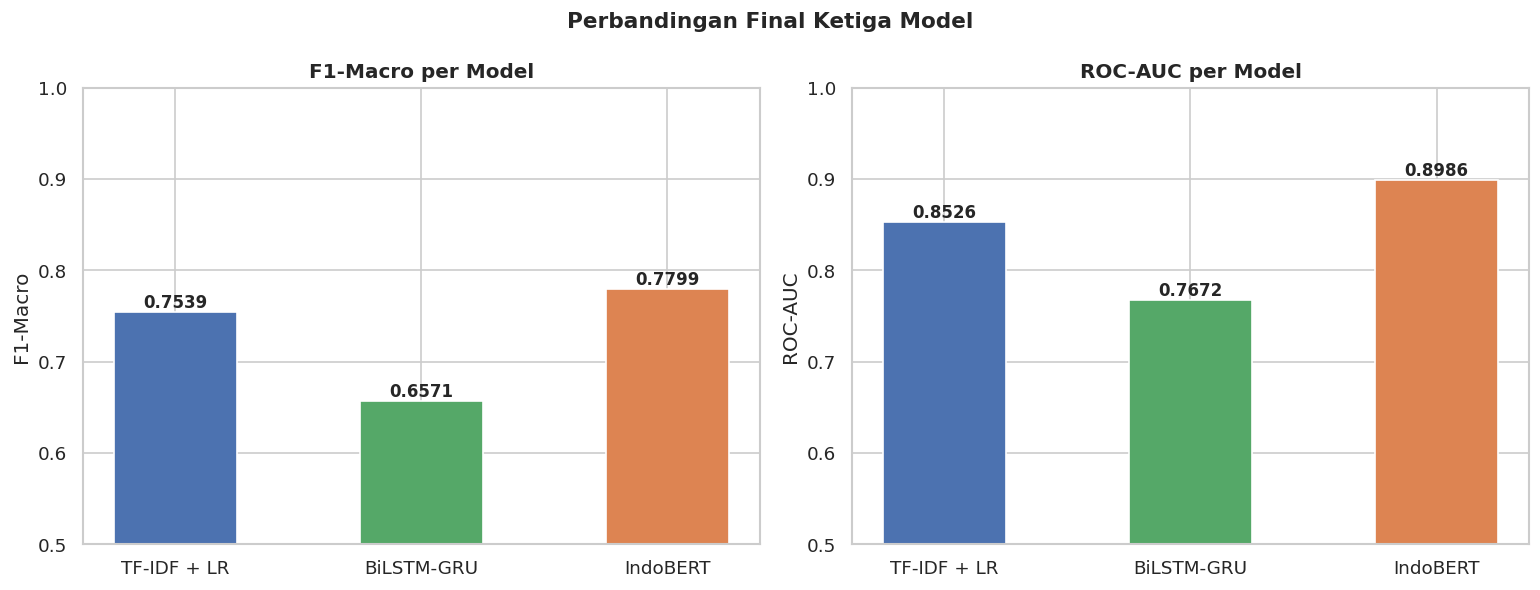

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4C72B0', '#55A868', '#DD8452']
models = results_final['Model'].tolist()

for ax, metric, title in [
    (axes[0], 'F1-Macro', 'F1-Macro per Model'),
    (axes[1], 'ROC-AUC',  'ROC-AUC per Model'),
]:
    bars = ax.bar(models, results_final[metric], color=colors, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0.5, 1.0)
    for bar, val in zip(bars, results_final[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center',
                fontweight='bold', fontsize=10)

plt.suptitle('Perbandingan Final Ketiga Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_16_final_comparison.png', bbox_inches='tight')
plt.show()

## Confusion Matrix & ROC Curve

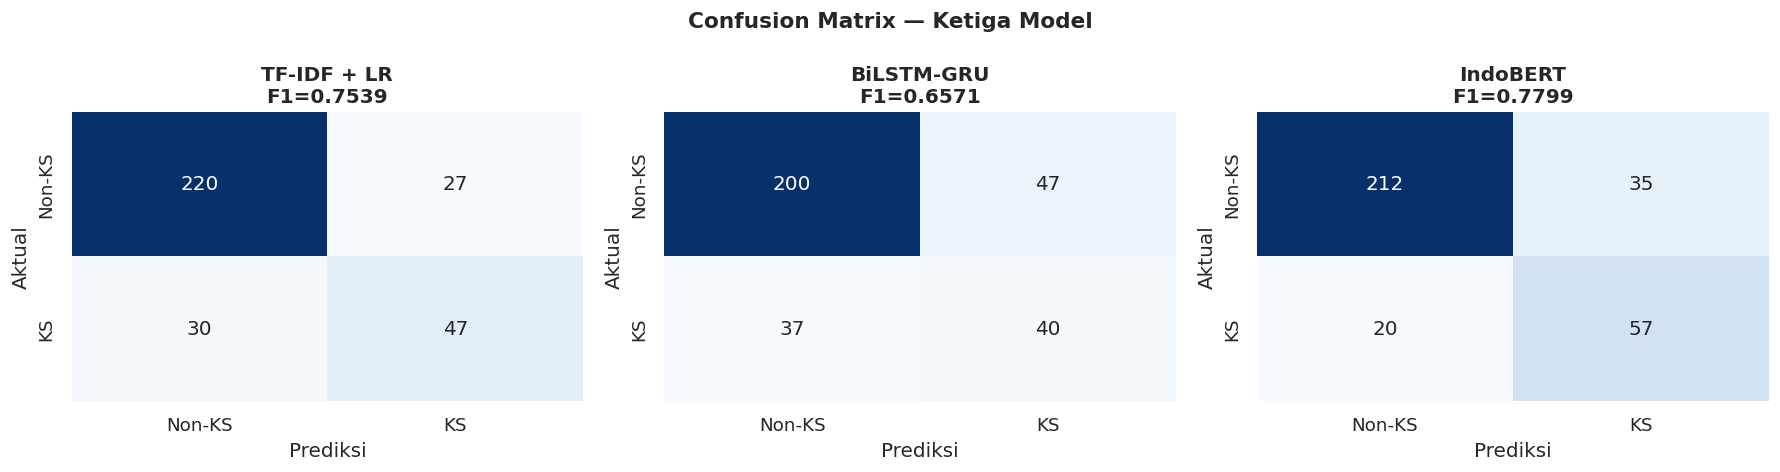

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nama, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar=False,
                xticklabels=['Non-KS', 'KS'],
                yticklabels=['Non-KS', 'KS'])
    f1 = f1_score(y_test, preds, average='macro')
    ax.set_title(f'{nama}\nF1={f1:.4f}', fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Ketiga Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_17_confusion_matrices.png', bbox_inches='tight')
plt.show()

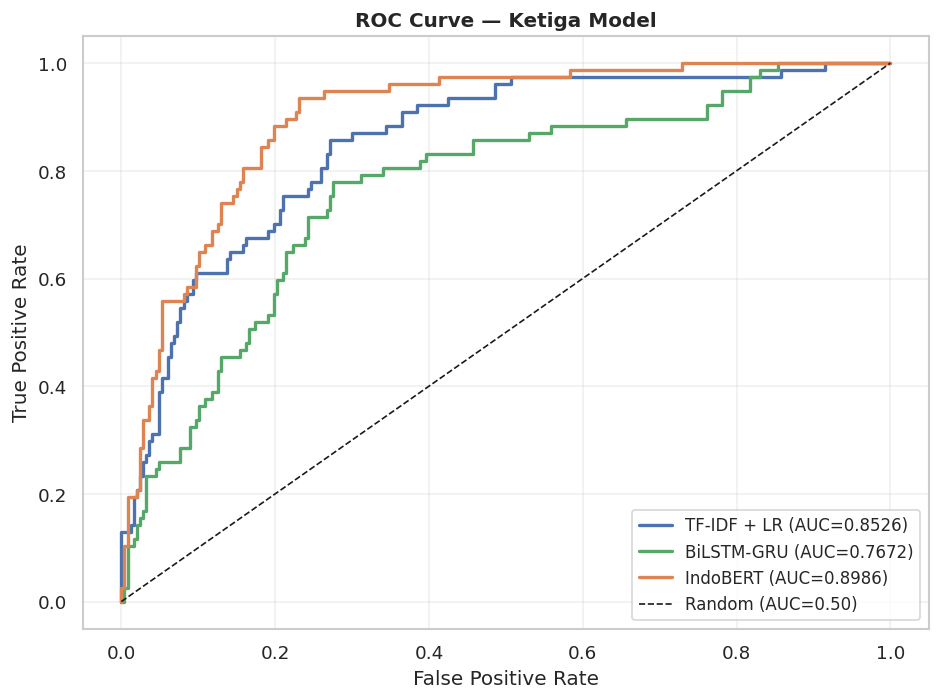

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for (nama, probs), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{nama} (AUC={roc_auc:.4f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Ketiga Model', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_18_roc_curves.png', bbox_inches='tight')
plt.show()

## Error Analysis

In [ ]:
print("=" * 65)
print("ERROR ANALYSIS — TIPE KESALAHAN PER MODEL")
print("=" * 65)
print()
for nama, preds in all_preds.items():
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_ks     = fn + tp
    total_non_ks = tn + fp
    print(f"Model: {nama}")
    print(f"  TP — KS terdeteksi benar     : {tp:>4}/{total_ks}")
    print(f"  FN — KS tidak terdeteksi     : {fn:>4}/{total_ks} ← berbahaya")
    print(f"  TN — Non-KS benar            : {tn:>4}/{total_non_ks}")
    print(f"  FP — Non-KS salah flagged    : {fp:>4}/{total_non_ks}")
    print(f"  Recall KS    : {tp/(tp+fn):.4f}")
    print(f"  Precision KS : {tp/(tp+fp):.4f}")
    print()

ERROR ANALYSIS — TIPE KESALAHAN PER MODEL

Model: TF-IDF + LR
  TP — KS terdeteksi benar     :   47/77
  FN — KS tidak terdeteksi     :   30/77 ← berbahaya
  TN — Non-KS benar            :  220/247
  FP — Non-KS salah flagged    :   27/247
  Recall KS    : 0.6104
  Precision KS : 0.6351

Model: BiLSTM-GRU
  TP — KS terdeteksi benar     :   40/77
  FN — KS tidak terdeteksi     :   37/77 ← berbahaya
  TN — Non-KS benar            :  200/247
  FP — Non-KS salah flagged    :   47/247
  Recall KS    : 0.5195
  Precision KS : 0.4598

Model: IndoBERT
  TP — KS terdeteksi benar     :   57/77
  FN — KS tidak terdeteksi     :   20/77 ← berbahaya
  TN — Non-KS benar            :  212/247
  FP — Non-KS salah flagged    :   35/247
  Recall KS    : 0.7403
  Precision KS : 0.6196



##  Ringkasan Final

In [ ]:
print("=" * 65)
print("RINGKASAN FINAL — PIPELINE UAS DSD09")
print("=" * 65)
print()
print("SOAL 1a — Feature Selection")
print("  Chi-Square : 3030→1000 fitur, F1=0.7418 (↓0.0049)")
print("  RFE        : 3030→1000 fitur, F1=0.7397 (↓0.0070)")
print("  → Reduksi 67% fitur, penurunan F1 < 0.01")
print()
print("SOAL 1b — Dimensionality Reduction")
print("  PCA (n=100): F1=0.7366, var=44.8% (↓0.0101)")
print("  t-SNE      : visualisasi separabilitas kelas")
print("  → PCA tidak efektif untuk TF-IDF sparse")
print()
print("SOAL 2 — SMOTE")
print("  Sebelum : F1=0.7467, AUC=0.8475")
print("  Setelah : F1=0.7539, AUC=0.8525 (↑0.0072)")
print()
print("SOAL 3a — GridSearchCV")
print("  100 fits, waktu=17.9 detik")
print("  F1: 0.7467 → 0.7539 (↑0.0072)")
print("  Param optimal: C=1, solver=saga, penalty=l2")
print()
print("SOAL 3b — Stratified K-Fold (K=5)")
print("  LR Default : 0.7283 ± 0.0153")
print("  LR Optimal : 0.7271 ± 0.0164")
print("  Train-Val gap ~0.17 → overfitting moderat")
print()
print("EVALUASI FINAL KETIGA MODEL")
print(results_final[['Model','F1-Macro','ROC-AUC',
                      'Waktu Train (s)']].to_string(index=False))
print()
print(f"→ IndoBERT terbaik   : F1={f1_bert:.4f}, AUC={auc_bert:.4f}")
print(f"→ TF-IDF+LR solid   : F1={f1_lr:.4f}, 2500x lebih cepat")
print(f"→ BiLSTM-GRU limited: F1={f1_bilstm:.4f}, data kurang untuk DL")
print()
print("=" * 65)
print("SEMUA PIPELINE SELESAI ✓")
print("=" * 65)

RINGKASAN FINAL — PIPELINE UAS DSD09

SOAL 1a — Feature Selection
  Chi-Square : 3030→1000 fitur, F1=0.7418 (↓0.0049)
  RFE        : 3030→1000 fitur, F1=0.7397 (↓0.0070)
  → Reduksi 67% fitur, penurunan F1 < 0.01

SOAL 1b — Dimensionality Reduction
  PCA (n=100): F1=0.7366, var=44.8% (↓0.0101)
  t-SNE      : visualisasi separabilitas kelas
  → PCA tidak efektif untuk TF-IDF sparse

SOAL 2 — SMOTE
  Sebelum : F1=0.7467, AUC=0.8475
  Setelah : F1=0.7539, AUC=0.8525 (↑0.0072)

SOAL 3a — GridSearchCV
  100 fits, waktu=17.9 detik
  F1: 0.7467 → 0.7539 (↑0.0072)
  Param optimal: C=1, solver=saga, penalty=l2

SOAL 3b — Stratified K-Fold (K=5)
  LR Default : 0.7283 ± 0.0153
  LR Optimal : 0.7271 ± 0.0164
  Train-Val gap ~0.17 → overfitting moderat

EVALUASI FINAL KETIGA MODEL
      Model  F1-Macro  ROC-AUC  Waktu Train (s)
TF-IDF + LR    0.7539   0.8526             0.04
 BiLSTM-GRU    0.6571   0.7672           118.20
   IndoBERT    0.7799   0.8986           126.80

→ IndoBERT terbaik   : F1=0.

In [ ]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/SIMULATION MODELLING AND ANALYSIS/Tugas Jurnal (Kelompok 5)/Code/Hasil_code_v2'
os.makedirs(save_dir, exist_ok=True)

# Simpan semua file dari working directory
saved, skipped = [], []

for f in os.listdir('/content'):
    src = f'/content/{f}'
    # Skip folder sistem dan drive
    if f in ['drive', 'sample_data', '.config', 'sys', 'proc']:
        continue
    if os.path.isfile(src):
        shutil.copy(src, os.path.join(save_dir, f))
        saved.append(f)
    elif os.path.isdir(src):
        dst = os.path.join(save_dir, f)
        shutil.copytree(src, dst, dirs_exist_ok=True)
        saved.append(f + '/')

print(f"Tersimpan ({len(saved)} item):")
for f in sorted(saved):
    print(f"  ✓ {f}")

Mounted at /content/drive
Tersimpan (35 item):
  ✓ X_train_smote.pkl
  ✓ dataset_fix - scraped_tweets_5.csv
  ✓ dataset_preprocessed.csv
  ✓ feature_selection_results.csv
  ✓ final_model_comparison.csv
  ✓ gridsearch_results.csv
  ✓ indobert_best.pt
  ✓ indobert_finetuned/
  ✓ lr_optimal.pkl
  ✓ model_bilstm_gru.h5
  ✓ pca_results.csv
  ✓ plot_01_class_distribution.png
  ✓ plot_02_text_length.png
  ✓ plot_03_profanity_density.png
  ✓ plot_04_lexical_bias_iou.png
  ✓ plot_05_log_odds.png
  ✓ plot_06_wordcloud.png
  ✓ plot_07_feature_selection.png
  ✓ plot_08_pca_variance.png
  ✓ plot_09_pca_tradeoff.png
  ✓ plot_10_tsne.png
  ✓ plot_11_smote_comparison.png
  ✓ plot_12_confusion_matrix_smote.png
  ✓ plot_13_gridsearch.png
  ✓ plot_14_kfold.png
  ✓ plot_15_bilstm_history.png
  ✓ plot_16_final_comparison.png
  ✓ plot_17_confusion_matrices.png
  ✓ plot_18_roc_curves.png
  ✓ selector_chi2.pkl
  ✓ selector_rfe.pkl
  ✓ smote_results.csv
  ✓ tfidf_vectorizer.pkl
  ✓ tokenizer_bilstm.pkl
  ✓ y_t